**Import library and Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/kel6-internbcc/Student_DropOut.csv', delimiter=';', encoding='utf-8', decimal=',')

Mounted at /content/drive


**Cek missing value**

In [ ]:
df.isna().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


**Cek jumlah duplikat**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Marital status                                  4424 non-null   int64 
 1   Application mode                                4424 non-null   int64 
 2   Application order                               4424 non-null   int64 
 3   Course                                          4424 non-null   int64 
 4   Daytime/evening attendance	                     4424 non-null   int64 
 5   Previous qualification                          4424 non-null   int64 
 6   Previous qualification (grade)                  4424 non-null   object
 7   Nacionality                                     4424 non-null   int64 
 8   Mother's qualification                          4424 non-null   int64 
 9   Father's qualification                          4424

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666.666.666.666.600,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,Graduate


Pada dataset terdapat beberapa fitur, seperti Marital status, Application mode, Application order,                               Course, Nacionality                ,Mother's qualification, Father's qualification,                Mother's occupation, Father's occupation                   yang sudah berubah menjadi numerik, tetapi berisi nilai angka kode unik, seperti kode pekerjaan atau jurusan yang merupakan data nominal (jenis data kategorikal yang melabeli variabel tanpa urutan atau peringkat), sehingga jika dimasukkan ke dalam pemodelan, angka tersebut akan disalahpahami sebagai data ordinal atau data kategorikal yang memiliki urutan. Oleh karena itu, fitur-fitur tersebut harus diubah kembali dari numerik ke category. Selain itu, fitur seperti, Debtor, Tuition fees up to date, Gender, Scholarship holder, Displaced, Educational special needs, Daytime/evening attendance, dan International sudah diencode menggunakan label encoder menjadi binary, tetapi untuk memudahkan expolatory data analysis, nilai binary diubah kembali ke nilai string sebenarnya.    

In [ ]:
def map_categorical_features(df):
    """
    Mapping fitur kategorikal dari angka ke string label
    untuk keperluan EDA dan visualisasi.

    Fitur numerik (Performa Akademik & Makroekonomi) tidak dimapping.
    """

    # A. DEMOGRAFI

    mapping_marital = {
        1: "Single",
        2: "Married",
        3: "Widower",
        4: "Divorced",
        5: "Facto union",
        6: "Legally separated"
    }

    mapping_nationality = {
        1: "Portuguese", 2: "German", 6: "Spanish",
        11: "Italian", 13: "Dutch", 14: "English",
        17: "Lithuanian", 21: "Angolan", 22: "Cape Verdean",
        24: "Guinean", 25: "Mozambican", 26: "Santomean",
        32: "Turkish", 41: "Brazilian", 62: "Romanian",
        100: "Moldovan", 101: "Mexican", 103: "Ukrainian",
        105: "Russian", 108: "Cuban", 109: "Colombian"
    }

    mapping_international = {
        1: "Yes",
        0: "No"
    }

    mapping_gender = {
        1: "Male",
        0: "Female"
    }

    mapping_displaced = {
        1: "Yes",
        0: "No"
    }

    # B. SOSIAL-EKONOMI

    mapping_mothers_qualification = {
        1: "Secondary Education - 12th Year",
        2: "Higher Education - Bachelor's Degree",
        3: "Higher Education - Degree",
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: "Frequency of Higher Education",
        9: "12th Year of Schooling- Not Completed",
        10: "11th Year of Schooling - Not Completed",
        11: "7th Year (Old)",
        12: "Other - 11th Year of Schooling",
        14: "10th Year of Schooling",
        18: "General Commerce Course",
        19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv",
        22: "Technical-professional Course",
        26: "7th Year of Schooling",
        27: "2nd Cycle of the General High School Course",
        29: "9th Year - Not Completed",
        30: "8th Year of Schooling",
        34: "Unknown",
        35: "Can't Read or Write",
        36: "Can Read Without having a 4th year of schooling",
        37: "Basic Education 1st Cycle (4th/5th year) or equiv.",
        38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.",
        39: "Technological Specialization Course",
        40: "Higher Education - Degree (1st Cycle)",
        41: "Specialized Higher Studies Course",
        42: "Professional Higher Technical Course",
        43: "Higher Education - Master (2nd Cycle)",
        44: "Higher Education - Doctorate (3rd Cycle)"
    }

    mapping_fathers_qualification = {
        1: "Secondary Education - 12th Year of Schooling or Eq.",
        2: "Higher Education - Bachelor's Degree",
        3: "Higher Education - Degree",
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: "Frequency of Higher Education",
        9: "12th Year of Schooling - Not Completed",
        10: "11th Year of Schooling - Not Completed",
        11: "7th Year (Old)",
        12: "Other - 11th Year of Schooling",
        13: "2nd Year Complementary High School Course",
        14: "10th Year of Schooling",
        18: "General Commerce Course",
        19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.",
        20: "Complementary High School Course",
        22: "Technical-professional Course",
        25: "Complementary High School - Not Concluded",
        26: "7th Year of Schooling",
        27: "2nd Cycle General High School Course",
        29: "9th Year of Schooling - Not Completed",
        30: "8th Year of Schooling",
        31: "General Course of Administration and Commerce",
        33: "Supplementary Accounting and Administration",
        34: "Unknown",
        35: "Can't Read or Write",
        36: "Can Read Without a 4th year of schooling ",
        37: "Basic Education 1st Cycle (4th/5th year) or equiv.",
        38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. ",
        39: "Technological Specialization Course",
        40: "Higher Education - Degree (1st Cycle)",
        41: "Specialized Higher Studies Course",
        42: "Professional Higher Technical Course",
        43: "Higher Education - Master (2nd Cycle)",
        44: "Higher Education - Doctorate (3rd Cycle)"
    }

    mapping_mothers_occupation = {
        0: "Student",
        1: "Legislative and Executive Bodies Directors/Managers",
        2: "Specialists in Intellectual & Scientific Activities",
        3: "Intermediate Level Technicians and Professions",
        4: "Administrative Staff",
        5: "Personal Services, Security and Safety Workers, and Sellers",
        6: "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
        7: "Skilled Workers in Industry, Construction, and Craftsmen",
        8: "Installation and Machine Operators and Assembly Workers",
        9: "Unskilled Workers",
        10: "Armed Forces Professions",
        90: "Other Situation",
        99: "Blank",
        122: "Health Professionals",
        123: "Teachers",
        125: "Specialists in Information and Communication Technologies (ICT)",
        131: "Intermediate Level Science & Engineering Technicians",
        132: "Technicians and Professionals of Intermediate Level of Health",
        134: "Intermediate Level Technicians from Legal, Social, Sports, Cultural and Similar Services",
        141: "Office Workers, Secretaries in General and Data Processing Operators",
        143: "Data, Accounting, Statistical, Financial Services and Registry-related Operators",
        144: "Other Administrative Support Staff",
        151: "Personal Service Workers",
        152: "Sellers",
        153: "Personal Care Workers",
        171: "Skilled Construction Workers and The Like, except Electricians",
        173: "Skilled Workers in Printing & Precision Instrument Manufacturing, Jewelers, Artisans",
        175: "Workers in Food Processing, Woodworking Clothing  and Other Industries and Crafts",
        191: "Cleaning Workers",
        192: "Unskilled Workers in Agriculture, Animal Production, Fisheries and Forestry",
        193: "Unskilled Workers in Extractive Industry, Construction, Manufacturing and Transport",
        194: "Meal Preparation Assistants"
    }

    mapping_fathers_occupation = {
        0: "Student",
        1: "Legislative and Executive Bodies Directors/Managers",
        2: "Specialists in Intellectual and Scientific Activities",
        3: "Intermediate Level Technicians",
        4: "Administrative Staff",
        5: "Personal Services, Security and Safety Workers, and Sellers",
        6: "Farmers and Skilled Workers in Agriculture, Fisheries, and Forestry",
        7: "Skilled Workers in Industry, Construction, and Craftsmen",
        8: "Installation and Machine Operators and Assembly",
        9: "Unskilled Workers",
        10: "Armed Forces Professions",
        90: "Other Situation",
        99: "Blank",
        101: "Armed Forces Officers",
        102: "Armed Forces Sergeants",
        103: "Other Armed Forces Personnel",
        112: "Directors of Administrative and Commercial Services",
        114: "Hotel, Catering, Trade, and Other Services Directors",
        121: "Physical Sciences, Math & Engineering (Sp)",
        122: "Health Professionals",
        123: "Teachers",
        124: "Finance, Accounting, Administrative Organization, Public and Commercial Relations (Sp)",
        131: "Intermediate Level Science and Engineering Technicians and Professions",
        132: "Technicians and Professionals of Intermediate Level of Health",
        134: "Intermediate Level Technicians from Legal, Social, Sports, Cultural and Similar Services",
        135: "Information and Communication Technology Technicians",
        141: "Office Workers, Secretaries in General and Data Processing Operators",
        143: "Data, Accounting, Statistical, Financial Services and Registry-related Operators",
        144: "Other Administrative Support Staff",
        151: "Personal Service Workers",
        152: "Sellers",
        153: "Personal Care Workers",
        154: "Protection and Security Services Personnel",
        161: "Market-oriented Farmers and Skilled Agricultural and Animal Production Workers",
        163: "Farmers, Livestock Keepers, Fishermen, Hunters and Gatherers, Subsistence",
        171: "Skilled Construction Workers and The Like, except Electricians",
        172: "Skilled Workers in Metallurgy, Metalworking and Similar",
        174: "Skilled Workers in Electricity and Electronics",
        175: "Workers in Food Processing, Woodworking, Clothing and Other Industries and Crafts",
        181: "Fixed Plant and Machine Operators",
        182: "Assembly Workers",
        183: "Vehicle Drivers and Mobile Equipment Operators",
        192: "Unskilled Workers in Agriculture, Animal Production, Fisheries and Forestry",
        193: "Unskilled Workers in Extractive Industry, Construction, Manufacturing and Transport",
        194: "Meal Preparation Assistants",
        195: "Street Vendors"
    }

    mapping_special_needs = {1: "Yes", 0: "No"}
    mapping_debtor = {1: "Yes", 0: "No"}
    mapping_tuition = {1: "Yes", 0: "No"}
    mapping_scholarship = {1: "Yes", 0: "No"}

    # C. JALUR AKADEMIK

    mapping_application_mode = {
        1: "1st Phase - General Contingent",
        2: "Ordinance No. 612/93",
        5: "1st Phase - Special Contingent (Azores)",
        7: "Holders of Other Higher Courses",
        10: "Ordinance No. 854-B/99",
        15: "International Student (Bachelor)",
        16: "1st Phase - Special Contingent (Madeira)",
        17: "2nd Phase - General Contingent",
        18: "3rd Phase - General Contingent",
        26: "Ordinance No. 533-A/99 item b2",
        27: "Ordinance No. 533-A/99 item b3",
        39: "Over 23 Years Old",
        42: "Transfer",
        43: "Change of Course",
        44: "Technological Specialization Diploma",
        51: "Change of Institution/Course",
        53: "Short Cycle Diploma Holders",
        57: "Change of Institution/Course (International)"
    }

    mapping_course = {
        33: "Biofuel Production Technologies",
        171: "Animation and Multimedia Design",
        8014: "Social Service (Evening)",
        9003: "Agronomy",
        9070: "Communication Design",
        9085: "Veterinary Nursing",
        9119: "Informatics Engineering",
        9130: "Equinculture",
        9147: "Management",
        9238: "Social Service",
        9254: "Tourism",
        9500: "Nursing",
        9556: "Oral Hygiene",
        9670: "Advertising and Marketing Management",
        9773: "Journalism and Communication",
        9853: "Basic Education",
        9991: "Management (Evening)"
    }

    mapping_attendance = {
        1: "Daytime",
        0: "Evening"
    }

    mapping_previous_qualification = {
        1: "Secondary Education",
        2: "Higher Education - Bachelor's Degree",
        3: "Higher Education - Degree",
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: "Frequency of Higher Education",
        9: "12th Year - Not Completed",
        10: "11th Year - Not Completed",
        12: "Other - 11th Year",
        14: "10th Year",
        15: "10th Year - Not Completed",
        19: "Basic Education 3rd Cycle",
        38: "Basic Education 2nd Cycle",
        39: "Technological Specialization Course",
        40: "Higher Education - Degree (1st Cycle)",
        42: "Professional Higher Technical Course",
        43: "Higher Education - Master (2nd Cycle)"
    }

    mapping_application_order = {
    0: "1st Choice",
    1: "2nd Choice",
    2: "3rd Choice",
    3: "4th Choice",
    4: "5th Choice",
    5: "6th Choice",
    6: "7th Choice",
    7: "8th Choice",
    8: "9th Choice",
    9: "Last Choice"
    }

    # APPLY SEMUA MAPPING

    mappings = {
        # Demografi
        "Marital status":               mapping_marital,
        "Nacionality":                  mapping_nationality,
        "International":                mapping_international,
        "Gender":                       mapping_gender,
        "Displaced":                    mapping_displaced,
        # Sosial-Ekonomi
        "Mother's qualification":       mapping_mothers_qualification,
        "Father's qualification":       mapping_fathers_qualification,
        "Mother's occupation":          mapping_mothers_occupation,
        "Father's occupation":          mapping_fathers_occupation,
        "Educational special needs":    mapping_special_needs,
        "Debtor":                       mapping_debtor,
        "Tuition fees up to date":      mapping_tuition,
        "Scholarship holder":           mapping_scholarship,
        # Jalur Akademik
        "Application mode":             mapping_application_mode,
        "Application order":            mapping_application_order,
        "Course":                       mapping_course,
        "Daytime/evening attendance\t":   mapping_attendance,
        "Previous qualification":       mapping_previous_qualification,
    }

    df_eda = df.copy()
    for col, mapping in mappings.items():
        df_eda[col] = df_eda[col].map(mapping).astype('category')

    return df_eda


df_eda = map_categorical_features(df)

print(df_eda.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Marital status                                  4424 non-null   category
 1   Application mode                                4424 non-null   category
 2   Application order                               4424 non-null   category
 3   Course                                          4424 non-null   category
 4   Daytime/evening attendance	                     4424 non-null   category
 5   Previous qualification                          4424 non-null   category
 6   Previous qualification (grade)                  4424 non-null   object  
 7   Nacionality                                     4424 non-null   category
 8   Mother's qualification                          4424 non-null   category
 9   Father's qualification        

Fitur-fitur seperti, Previous qualification, Admission grade, Curricular units 1st sem (grade), 1 Curricular units 2nd sem (grade), Unemployment rate, Inflation rate, GDP fitur-fitur tersebut yang seharusnya berisi nilai numerik pada dataset tersebut malah terbaca sebagai object, sehingga fitur tersebut tipe datanya harus diubah ke numerik.

In [ ]:
print(df_eda['Previous qualification (grade)'].value_counts(),
      df_eda['Admission grade'].value_counts(),
      df_eda['Unemployment rate'].value_counts(),
      df_eda['Inflation rate'].value_counts(),
      df_eda['GDP'].value_counts(),
      sep='\n\n'
    )

Previous qualification (grade)
133.1    491
130.0    375
140.0    336
120.0    278
150.0    162
        ... 
169.0      1
138.7      1
119.1      1
118.9      1
126.6      1
Name: count, Length: 101, dtype: int64

Admission grade
130.0    162
140.0    153
120.0    145
100.0    116
150.0     81
        ... 
162.1      1
103.8      1
156.2      1
165.2      1
103.6      1
Name: count, Length: 620, dtype: int64

Unemployment rate
7.6     571
9.4     533
10.8    525
12.4    445
12.7    419
11.1    414
15.5    397
13.9    390
8.9     368
16.2    362
Name: count, dtype: int64

Inflation rate
1.4     893
2.6     571
-0.8    533
0.5     445
3.7     419
0.6     414
2.8     397
-0.3    390
0.3     362
Name: count, dtype: int64

GDP
0.32     571
-3.12    533
1.74     525
1.79     445
-1.7     419
2.02     414
-4.06    397
0.79     390
3.51     368
-0.92    362
Name: count, dtype: int64


In [ ]:
def convert_numeric_columns(df_eda, cols):
    for col in cols:
        # ubah koma jadi titik jika ada
        df_eda[col] = df_eda[col].astype(str).str.replace(',', '.', regex=False)

        # convert ke numeric
        df_eda[col] = pd.to_numeric(df_eda[col])

        if (df_eda[col].dropna() % 1 == 0).all():
            df_eda[col] = df_eda[col].astype('Int64')

    return df_eda

numeric_object_cols = [
    'Previous qualification (grade)',
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

df_eda = convert_numeric_columns(df_eda, numeric_object_cols)

In [ ]:
df_eda[['Previous qualification (grade)',
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP']].info()

df_eda[['Previous qualification (grade)',
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP']].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Previous qualification (grade)  4424 non-null   float64
 1   Admission grade                 4424 non-null   float64
 2   Unemployment rate               4424 non-null   float64
 3   Inflation rate                  4424 non-null   float64
 4   GDP                             4424 non-null   float64
dtypes: float64(5)
memory usage: 172.9 KB


Previous qualification (grade)  Admission grade  Unemployment rate  Inflation rate  GDP  
140.0                           140.0            12.4                0.5             1.79    27
                                                 15.5                2.8            -4.06    18
                                                 13.9               -0.3             0.79    17
130.0                           130.0            15.5                2.8            -4.06    15
                                                 12.4                0.5             1.79    15
                                                                                             ..
128.0                           125.6            8.9                 1.4             3.51     1
                                                 12.4                0.5             1.79     1
                                125.8            9.4                -0.8            -3.12     1
                                126.3            15.5                2.8            -4.06     1
                                124.2            7.6                 2.6             0.32     1
Name: count, Length: 3684, dtype: int64

In [ ]:
print(df_eda['Curricular units 2nd sem (grade)'].value_counts(),
      df_eda['Curricular units 2nd sem (grade)'].value_counts(),
      sep='\n\n')

Curricular units 2nd sem (grade)
0.0                       870
12.0                      170
11.0                      165
13.0                      150
11.5                       86
                         ... 
15.433.333.333.333.300      1
13.78                       1
15.11                       1
13.927.272.727.272.700      1
147.375                     1
Name: count, Length: 785, dtype: int64

Curricular units 2nd sem (grade)
0.0                       870
12.0                      170
11.0                      165
13.0                      150
11.5                       86
                         ... 
15.433.333.333.333.300      1
13.78                       1
15.11                       1
13.927.272.727.272.700      1
147.375                     1
Name: count, Length: 785, dtype: int64


Terdapat format angka yang desimal lebih dari satu koma

In [ ]:
cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for col in cols:
    mask = df_eda[col].astype(str).str.count(r'\.') > 1
    print(col, ":", mask.sum())

Curricular units 1st sem (grade) : 1633
Curricular units 2nd sem (grade) : 1476


Jumlah angka dengan format kesalahan seperti "13.927.272.727.272.700" sangat banyak, kemungkinan besar terjadi kesalahan pada penulisan nilai tersebut. Oleh karena itu, pembersihan pada penulisan koma dilakukan ke format yang benar.

In [ ]:
def fix_grade(col):
    col = col.astype(str)

    col = col.apply(
        lambda x: '.'.join(x.split('.')[:2]) if x.count('.') > 1 else x
    )

    return pd.to_numeric(col, errors='coerce')

grade_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for col in grade_cols:
    df_eda[col] = fix_grade(df_eda[col])
df_eda[grade_cols].info()
df_eda[grade_cols].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Curricular units 1st sem (grade)  4424 non-null   float64
 1   Curricular units 2nd sem (grade)  4424 non-null   float64
dtypes: float64(2)
memory usage: 69.3 KB


Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)
0.000                             0.000                               676
11.000                            0.000                                29
10.000                            0.000                                29
12.000                            0.000                                19
                                  11.000                               19
                                                                     ... 
133.125                           156.375                               1
132.575                           132.575                               1
132.375                           13.742                                1
132.325                           132.325                               1
128.375                           15.500                                1
Name: count, Length: 2634, dtype: int64

Dalam artikel penelitian dataset tersebut, dijelaskan bahwa Grade average in the 1st and 2nd semester (between 0 and 20)  https://doi.org/10.3390/data7110146 sehingga nilai diluar range tidak valid dan dapat diganti dengan median.

In [ ]:
for col in [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]:
    print(col, (~df_eda[col].between(0,20)).sum())

Curricular units 1st sem (grade) 39
Curricular units 2nd sem (grade) 82


In [ ]:
grade_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for col in grade_cols:

    # ubah nilai di luar 0–20 jadi NaN
    df_eda.loc[~df_eda[col].between(0, 20), col] = np.nan

    # isi dengan median
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

In [ ]:
for col in grade_cols:
    print(col, (~df_eda[col].between(0,20)).sum())

Curricular units 1st sem (grade) 0
Curricular units 2nd sem (grade) 0


In [ ]:
df_eda['Target'] = df_eda['Target'].astype('category')

In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Marital status                                  4424 non-null   category
 1   Application mode                                4424 non-null   category
 2   Application order                               4424 non-null   category
 3   Course                                          4424 non-null   category
 4   Daytime/evening attendance	                     4424 non-null   category
 5   Previous qualification                          4424 non-null   category
 6   Previous qualification (grade)                  4424 non-null   float64 
 7   Nacionality                                     4424 non-null   category
 8   Mother's qualification                          4424 non-null   category
 9   Father's qualification        

In [ ]:
df_eda.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd Phase - General Contingent,6th Choice,Animation and Multimedia Design,Daytime,Secondary Education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000,0,10.8,1.4,1.74,Dropout
1,Single,International Student (Bachelor),2nd Choice,Tourism,Daytime,Secondary Education,160.0,Portuguese,Secondary Education - 12th Year,Higher Education - Degree,...,0,6,6,6,13.666,0,13.9,-0.3,0.79,Graduate
2,Single,1st Phase - General Contingent,6th Choice,Communication Design,Daytime,Secondary Education,122.0,Portuguese,Basic Education 1st Cycle (4th/5th year) or eq...,Basic Education 1st Cycle (4th/5th year) or eq...,...,0,6,0,0,0.000,0,10.8,1.4,1.74,Dropout
3,Single,2nd Phase - General Contingent,3rd Choice,Journalism and Communication,Daytime,Secondary Education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic Education 1st Cycle (4th/5th year) or eq...,...,0,6,10,5,12.400,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 Years Old,2nd Choice,Social Service (Evening),Evening,Secondary Education,100.0,Portuguese,Basic Education 1st Cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000,0,13.9,-0.3,0.79,Graduate


**Statistik Deskriptif Dataset**

Setelah proses data cleaning dan type conversion, berikut adalah gambaran statistik keseluruhan dataset yang siap dianalisis.

In [ ]:
numerical_features = df_eda.select_dtypes(include='number').columns.tolist()

In [ ]:
df_eda[numerical_features].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.320955,0.137658,0.541817,6.232143,8.063291,4.435805,9.817474,0.150316,11.566139,1.228029,0.001969
std,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,5.030684,0.690880,1.918546,2.195951,3.947951,3.014764,5.372294,0.753774,2.663850,1.382711,2.269935
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,10.800000,0.000000,0.000000,5.000000,6.000000,2.000000,10.333000,0.000000,9.400000,0.300000,-1.700000
50%,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.166000,0.000000,0.000000,6.000000,8.000000,5.000000,12.000000,0.000000,11.100000,1.400000,0.320000
75%,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.333000,0.000000,0.000000,7.000000,10.000000,6.000000,13.200000,0.000000,13.900000,2.600000,1.790000
max,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571000,12.000000,16.200000,3.700000,3.510000


### Insight: Statistik Deskriptif

**Apa yang terlihat:**
- Dataset memiliki **4.424 baris dan 37 kolom** (36 fitur + 1 target)
- **Tidak ada missing value** — dataset sudah bersih sempurna (konsisten dengan temuan Realinho et al., 2022 yang memang merancang dataset bebas missing value)
- Fitur akademik seperti `Curricular units 1st/2nd sem (approved)` dan `(grade)` memiliki **distribusi sangat skewed ke kiri** untuk kelompok Dropout, artinya banyak mahasiswa DO yang tidak lulus satupun MK

**Catatan range:**
- Grade semester 1 & 2: skala 0–20 (sudah diperbaiki dari format error sebelumnya)
- Previous qualification grade & Admission grade: skala 0–200
- Makroekonomi (GDP, Unemployment, Inflation): nilai kontinu mencerminkan kondisi Portugal 2008–2019

**Relevansi ke Business Objective:**
Statistik deskriptif ini mengkonfirmasi bahwa dataset cukup representatif untuk membangun model klasifikasi multi-kelas (Dropout/Enrolled/Graduate) sesuai Business Objective 2 kita.

In [ ]:
from google.colab import files
df_eda.to_csv('dataset_clean.csv', index=False)
files.download('dataset_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_eda.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'}, inplace=True)

In [ ]:
def eda_binary(df_eda, col, title=None):
    title = title or col
    prop = pd.crosstab(df_eda[col], df_eda['Target'], normalize='index') * 100
    categories = prop.index.tolist()
    X_axis = np.arange(len(categories))
    total = df_eda[col].value_counts()

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.bar(total.index, total.values, color='steelblue', width=0.4)
    plt.title(f'Distribusi {title}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.grid(axis='y')

    plt.subplot(1, 2, 2)
    plt.bar(X_axis - 0.2, prop['Dropout'], 0.2, label='Dropout', color='red')
    plt.bar(X_axis, prop['Enrolled'], 0.2, label='Enrolled', color='skyblue')
    plt.bar(X_axis + 0.2, prop['Graduate'], 0.2, label='Graduate', color='mediumseagreen')
    plt.xticks(X_axis, categories)
    plt.title(f'Proporsi {title} per Status Akademik (%)')
    plt.ylabel('Proporsi (%)')
    plt.xlabel(col)
    plt.legend(title='Target')
    plt.grid(axis='y')
    plt.margins(x=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def eda_multicat(df_eda, col, title=None):
    target_order = ['Dropout', 'Enrolled', 'Graduate']
    colors = ['red', 'skyblue', 'mediumseagreen']
    bar_height = 0.25

    counts = df_eda[col].value_counts()
    jumlah_per_target = pd.crosstab(df_eda[col], df_eda['Target'])
    jumlah_per_target = jumlah_per_target.reindex(index=counts.index, columns=target_order, fill_value=0)
    proporsi = jumlah_per_target.div(jumlah_per_target.sum(axis=1), axis=0) * 100
    posisi = range(len(proporsi))

    plt.figure(figsize=(18, max(6, len(counts) * 0.5)))
    plt.suptitle(title or col, fontsize=14, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.barh(counts.index, counts.values, color='steelblue', edgecolor='white')
    plt.title('Distribusi Keseluruhan')
    plt.xlabel('Jumlah')
    for i, (kategori, jumlah) in enumerate(zip(counts.index, counts.values)):
        persen = jumlah / len(df_eda) * 100
        plt.text(jumlah + 5, i, f'{jumlah} ({persen:.1f}%)', va='center', fontsize=9)

    plt.subplot(1, 2, 2)
    for i, (target, color) in enumerate(zip(target_order, colors)):
        posisi_bar = [p + (i - 1) * bar_height for p in posisi]
        nilai_proporsi = proporsi[target].values
        nilai_jumlah = jumlah_per_target[target].values
        plt.barh(posisi_bar, nilai_proporsi, height=bar_height, label=target, color=color, edgecolor='white')
        for p, v, j in zip(posisi_bar, nilai_proporsi, nilai_jumlah):
            if v > 0:
                plt.text(v + 0.5, p, f'{j}', va='center', fontsize=8)
    plt.yticks(list(posisi), proporsi.index)
    plt.title('Proporsi per Status Akademik (%)')
    plt.xlabel('Proporsi (%)')
    plt.legend(title='Target')

    plt.tight_layout()
    plt.show()

    for target in target_order:
        print(f"{target} tertinggi: {proporsi[target].idxmax()} ({proporsi[target].max():.1f}%)")

In [ ]:
def eda_numeric(df_eda, col, title=None):
    target_order = ['Dropout', 'Enrolled', 'Graduate']
    colors = ['red', 'skyblue', 'mediumseagreen']

    title = title or col
    df_plot = df_eda[[col, 'Target']].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Histogram + KDE keseluruhan
    sns.histplot(df_plot[col], kde=True, color='steelblue', ax=axes[0])
    axes[0].set_title('Distribusi')
    axes[0].set_xlabel(col)
    axes[0].grid()

    # KDE per target
    for t, c in zip(target_order, colors):
        subset = df_plot[df_plot['Target'] == t][col]
        if len(subset) > 1:
            sns.kdeplot(subset, ax=axes[1], label=t, color=c)

    axes[1].set_title('Density per Target')
    axes[1].set_xlabel(col)
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

    stats = df_plot.groupby('Target')[col].agg(['mean', 'median', 'std', 'min', 'max'])
    print(stats.round(2))
    print()

**TARGET**

Status akhir mahasiswa pada akhir durasi normal program studi (3 tahun, kecuali Keperawatan 4 tahun). Tiga kategori: Dropout = tidak menyelesaikan studi, Enrolled = masih aktif kuliah, Graduate = telah menyelesaikan studi.

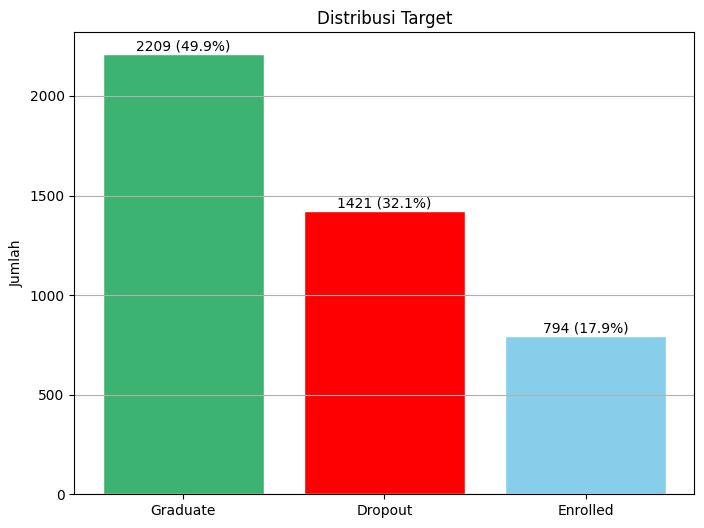

In [ ]:
target_counts = df_eda['Target'].value_counts()
total = len(df_eda)

plt.figure(figsize=(8, 6))
plt.bar(target_counts.index, target_counts.values,
        color=['mediumseagreen', 'red', 'skyblue'], edgecolor='white')

for i, (target, jumlah) in enumerate(zip(target_counts.index, target_counts.values)):
    persen = jumlah / total * 100
    plt.text(i, jumlah + 20, f'{jumlah} ({persen:.1f}%)', ha='center')

plt.title('Distribusi Target')
plt.ylabel('Jumlah')
plt.grid(axis='y')
plt.show()

### Insight: Curricular Units 2nd Sem - Without Evaluations (Tidak Ikut Ujian Sem 2)

**Apa yang terlihat:**
- Mahasiswa dengan banyak MK tanpa evaluasi di semester 2 hampir dipastikan **Dropout**
- Pola ini lebih kuat dari semester 1 karena di semester 2, alasan ketidakhadiran biasanya sudah permanen

**Hubungan dengan Dropout:**
- MK without evaluation = mahasiswa **terdaftar tapi tidak hadir** — sudah "ghost" dari kampus
- Semakin tinggi jumlah MK tanpa evaluasi di sem 2 → probabilitas dropout mendekati 100%

**Implikasi Early Warning System (Business Objective 1):**
> Data evaluasi semester 1 dan 2 bisa digunakan untuk membangun sistem peringatan dini
> yang mengidentifikasi mahasiswa berisiko bahkan **di pertengahan tahun pertama**.
> Ini adalah inti dari proyek kita: **deteksi dini sebelum mahasiswa benar-benar dropout**.




---



## ANALISIS BIVARIAT (2 VARIABEL)

Setelah melihat setiap fitur satu per satu, sekarang kita lihat **hubungan antar semua fitur sekaligus** menggunakan Correlation Matrix.

Feature correlation pada visualisasi tersebut dihitung menggunakan Pearson correlation untuk mengukur hubungan linear antar fitur numerik. Nilai korelasi berada pada rentang -1 hingga 1, di mana nilai mendekati -1 menunjukkan korelasi negatif yang kuat, nilai 0 menunjukkan tidak ada korelasi, dan nilai mendekati 1 menunjukkan korelasi positif yang kuat. Korelasi yang sangat tinggi antar fitur juga dapat mengindikasikan adanya multikolinieritas.

Text(0.5, 1.05, 'Feature Correlation')

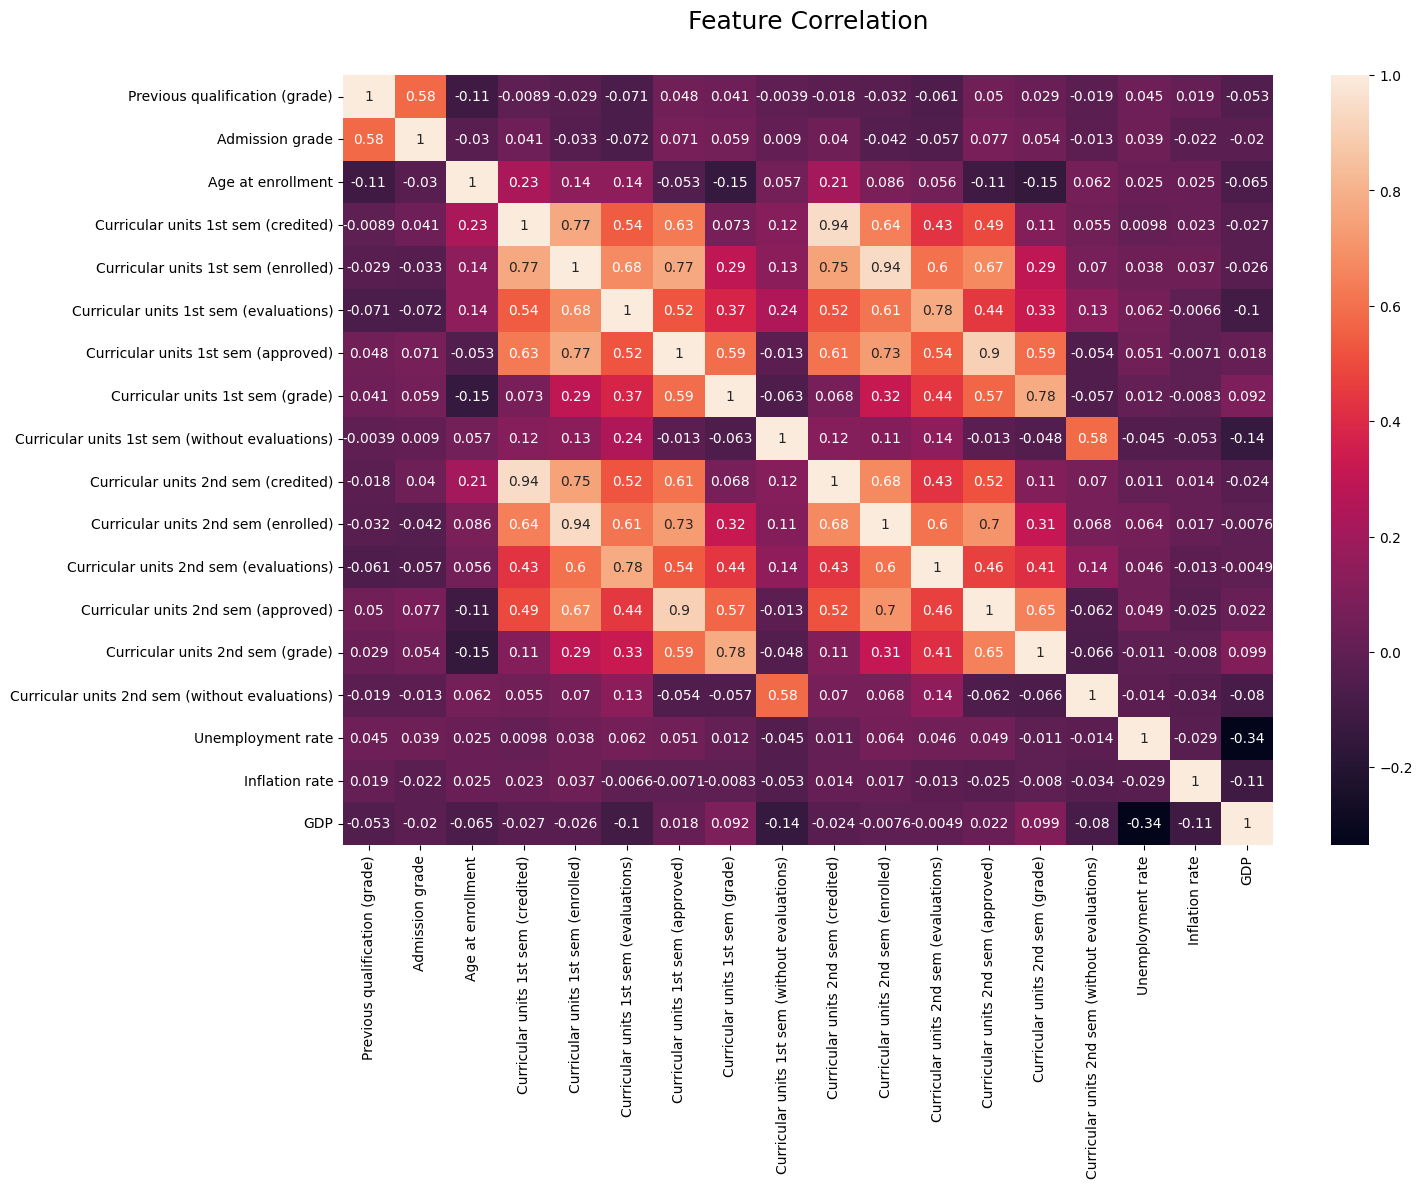

In [ ]:
plt.figure(figsize=(15,10))
num_feature = df_eda.select_dtypes(include=['number'])
sns.heatmap(num_feature.corr(), annot=True, cmap="rocket")
plt.title('Feature Correlation', fontsize=18, y=1.05)

Dari korelasi yang dihitung setiap fiturnya terdapat 3 fitur pasang fitur yang memiliki nilai multikolinieritas tinggi, sehingga dapat menyebabkan rendundansi. Fitur-fitur tersebut yaitu:

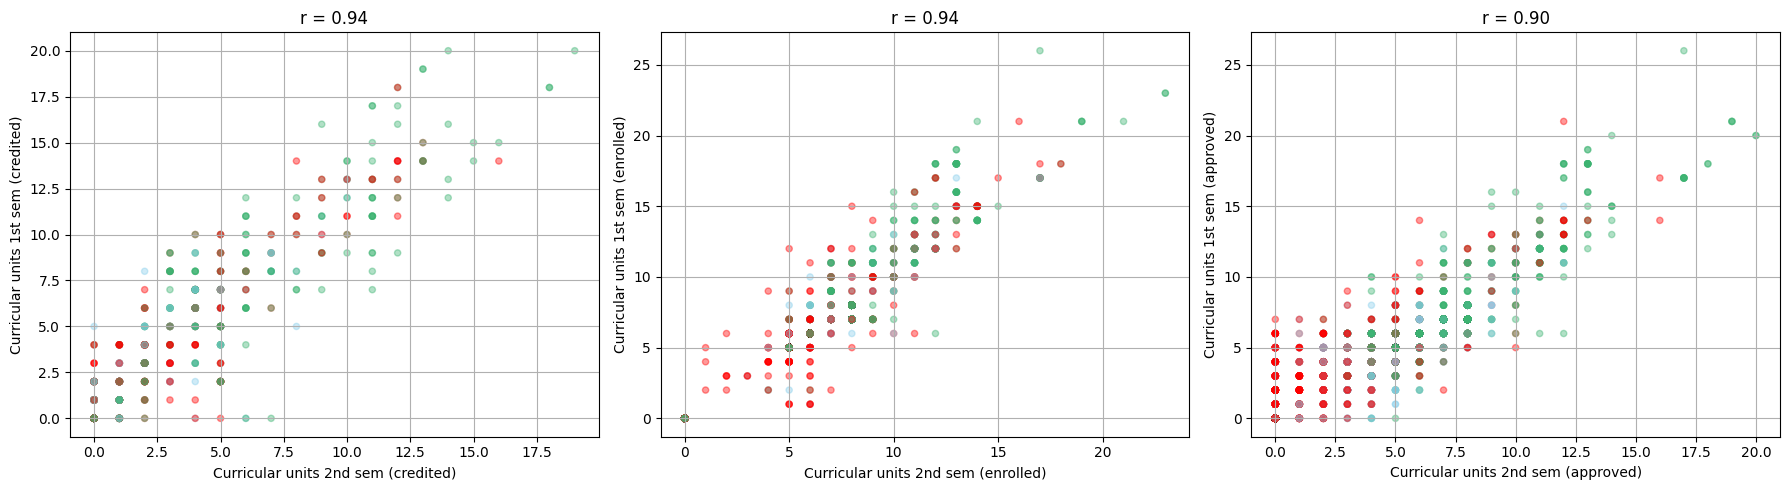

In [ ]:
num_feature = df_eda.select_dtypes(include=['number'])
corr_matrix = num_feature.corr().abs()
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).unstack().dropna().sort_values(ascending=False).reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
positif_tinggi = corr_pairs[corr_pairs['Correlation'] > 0.9]

colors = {'Dropout': 'red', 'Enrolled': 'skyblue', 'Graduate': 'mediumseagreen'}
scatter_colors = [colors[t] for t in df_eda['Target']]

n = len(positif_tinggi)
plt.figure(figsize=(6 * n, 5))

for i, (_, row) in enumerate(positif_tinggi.iterrows()):
    plt.subplot(1, n, i + 1)
    plt.scatter(df_eda[row['Feature 1']], df_eda[row['Feature 2']], c=scatter_colors, alpha=0.4, s=20)
    plt.title(f"r = {row['Correlation']:.2f}")
    plt.xlabel(row['Feature 1'])
    plt.ylabel(row['Feature 2'])
    plt.grid()

plt.tight_layout()
plt.show()

Ketiga scatter plot menunjukkan pasangan fitur dengan korelasi tinggi (r > 0.90)yang mengindikasikan multikolinearitas.

1. Curricular units 1st sem vs 2nd sem (credited): r = 0.94

    Mahasiswa yang mengambil banyak SKS credited di semester 1 cenderung juga mengambil banyak di semester 2. Pola ini wajar karena beban studi per semester biasanya konsisten.

2. Curricular units 1st sem vs 2nd sem (enrolled): r = 0.94

    Sama dengan credited, jumlah mata kuliah yang diambil di semester 1 dan 2 sangat berkorelasi. Mahasiswa yang aktif di satu semester cenderung aktif di semester berikutnya.

3. Curricular units 1st sem vs 2nd sem (approved): r = 0.90
    Mahasiswa yang lulus banyak mata kuliah di semester 1 cenderung lulus banyak juga di semester 2, mencerminkan konsistensi performa akademik.

Tujuan utama sistem ini adalah mendeteksi risiko dropout sedini mungkin agar institusi bisa melakukan intervensi sebelum terlambat. Dalam konteks ini, data semester 1 jauh lebih relevan karena merupakan informasi paling awal yang tersedia tentang performa akademik mahasiswa.

Jika model dibangun menggunakan data semester 2, prediksi baru bisa dilakukan setelah mahasiswa menyelesaikan satu tahun penuh. Pada kondisi ini kemungkinan besar mahasiswa yang berisiko sudah terlanjur dropout atau kondisinya sudah sulit diperbaiki. Sebaliknya, dengan data semester 1 institusi masih punya waktu untuk memberikan intervensi seperti konseling akademik, bantuan finansial, atau program mentoring sebelum situasi memburuk.

Selain itu, menghapus fitur semester 2 juga mengurangi multikolinearitas dalam model, sehingga prediksi menjadi lebih stabil dan interpretable.

**Mengecek Hubungan Independensi Antara Fitur Kategorikal ke Target dengan Chi-Square**



In [ ]:
kategorikal_fitur = df_eda.select_dtypes(include=['category'])
kategorikal_fitur.head(1)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International,Target
0,Single,2nd Phase - General Contingent,6th Choice,Animation and Multimedia Design,Daytime,Secondary Education,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,"Personal Services, Security and Safety Workers...",Unskilled Workers,Yes,No,No,Yes,Male,No,No,Dropout


Chi-Square adalah uji statistik yang dirancang khusus untuk mengukur apakah dua variabel kategorikal saling berhubungan atau tidak. Dalam dataset ini, terdapat 18 fitur kategorikal  dan untuk mengetahui apakah suatu fitur-fitur teresbut saling berhubungan  dengan target yang juga kategorikal (Dropout/Enrolled/Graduate) maka digunakan Chi-Square.  Namun, Chi-Square hanya bisa menjawab "ada hubungan atau tidak?" (dependen/independen) dan tidak bisa menjawab "seberapa kuat" hubungannya. Oleh karena itu, digunakan Bias-Corrected Cramér's V (Bergsma, 2013) untuk mengukur kekuatan hubungan dua variabel tersebut.


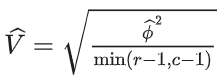

:https://doi.org/10.1016/j.jkss.2012.10.002

**Interpretation Cramer's V**

Nilai dari bias-correction for Cramér’s V (Bergsma, 2013), kemudian diinterpretasikan berdasarkan tabel berikut untuk merepresentasikan status hubungan antar kedua fitur kategorik.


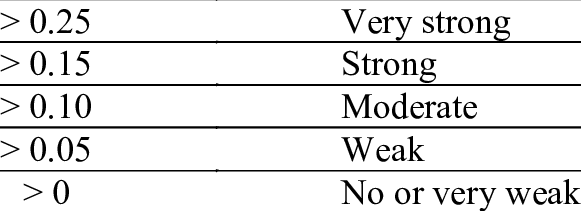

(Akoglu, 2018): https://doi.org/10.1016/j.tjem.2018.08.001

In [ ]:
from scipy import stats

def chi_square_test(df_eda, col1, col2, alpha=0.05):
    # Contingency table
    ct = pd.crosstab(df_eda[col1], df_eda[col2])

    # Chi-square test
    chi2, p_value, dof, expected = stats.chi2_contingency(ct)

    # Nilai kritis
    critical_value = stats.chi2.ppf(1 - alpha, dof)

    # Print hasil
    print(f"Contingency Table:\n{ct}\n")
    print(f"Chi-Square : {chi2:.4f}")

    if p_value < 0.001:
        print(f"P-Value    : < 0.001")
    else:
        print(f"P-Value    : {p_value:.4f}")
    print(f"Df         : {dof}")
    print(f"Nilai Kritis (α={alpha}): {critical_value:.4f}")
    print(f"Keputusan  : {'Tolak H0 → Dependen' if p_value < alpha else 'Terima H0 → Independen'}")


    # Plot distribusi
    x = np.linspace(0, max(chi2 * 1.5, critical_value * 1.5), 1000)
    y = stats.chi2.pdf(x, dof)

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, color='black')
    plt.fill_between(x, y, where=(x > critical_value), color='red', alpha=0.4, label=f'Critical Region (α={alpha})')
    plt.axvline(chi2, color='blue', linestyle='--', label=f'Chi-Square = {chi2:.4f}')
    plt.axvline(critical_value, color='red', linestyle='--', label=f'Critical Value = {critical_value:.4f}')
    plt.title(f'Chi-Square Test: {col1} vs {col2}')
    plt.legend()
    plt.grid()
    plt.show()

     # Bias-corrected Cramér's V
    n = ct.sum().sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    k_corr = k - (k-1)**2 / (n-1)
    r_corr = r - (r-1)**2 / (n-1)
    cramers = np.sqrt(phi2_corr / (min(k_corr, r_corr) - 1))

    if cramers > 0.25:
        asosiasi = "Very strong"
    elif cramers > 0.15:
        asosiasi = "Strong"
    elif cramers > 0.10:
        asosiasi = "Moderate"
    elif cramers > 0.05:
        asosiasi = "Weak"
    else:
        asosiasi = "No or very weak"
    print(f"Bias-Corrected Cramér's V : {cramers:.4f} → {asosiasi}")

In [ ]:
def interpretasi_kategorik(df_eda, col, title=None):
    target_order = ['Dropout', 'Enrolled', 'Graduate']
    colors = ['red', 'skyblue', 'mediumseagreen']

    counts = df_eda[col].value_counts()
    crosstab = pd.crosstab(df_eda[col], df_eda['Target'])
    crosstab = crosstab.reindex(index=counts.index, columns=target_order, fill_value=0)
    proporsi = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(9, max(6, len(counts) * 0.5)))
    plt.title(title or col, fontsize=14, fontweight='bold')

    bottom = np.zeros(len(proporsi))
    for target, color in zip(target_order, colors):
        vals = proporsi[target].values
        counts_val = crosstab[target].values
        plt.barh(range(len(proporsi)), vals, left=bottom, height=0.6,
                 label=target, color=color, edgecolor='white')
        for i, (v, j) in enumerate(zip(vals, counts_val)):
            if v > 3:
                plt.text(bottom[i] + v/2, i, str(j), va='center', ha='center', fontsize=8, color='white')
        bottom += vals

    plt.yticks(range(len(proporsi)), proporsi.index)
    plt.xlabel('Proporsi (%)')
    plt.legend(title='Target')
    plt.tight_layout()
    plt.show()

**1. Marital Status dan Target**

Contingency Table:
Target             Dropout  Enrolled  Graduate
Marital status                                
Divorced                42        16        33
Facto union             11         3        11
Legally separated        4         1         1
Married                179        52       148
Single                1184       720      2015
Widower                  1         2         1

Chi-Square : 63.4385
P-Value    : < 0.001
Df         : 10
Nilai Kritis (α=0.05): 18.3070
Keputusan  : Tolak H0 → Dependen


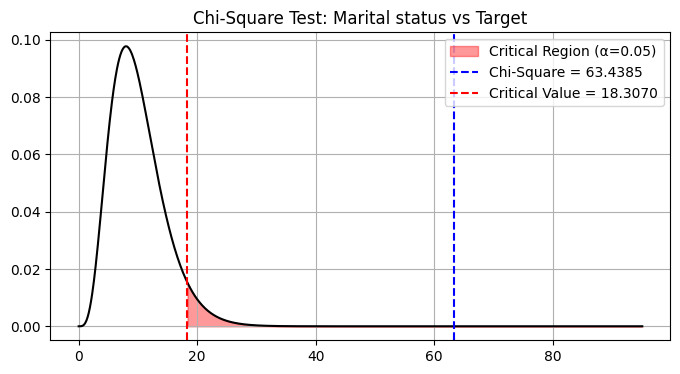

Bias-Corrected Cramér's V : 0.0777 → Weak


In [ ]:
chi_square_test(df_eda, 'Marital status', 'Target', alpha=0.05)

Chi-Square = 63.44 melampaui nilai kritis 18.31 dengan p-value < 0.001. Cramér's V = 0.0777 menunjukkan hubungan yang weak antara status pernikahan dan dropout.

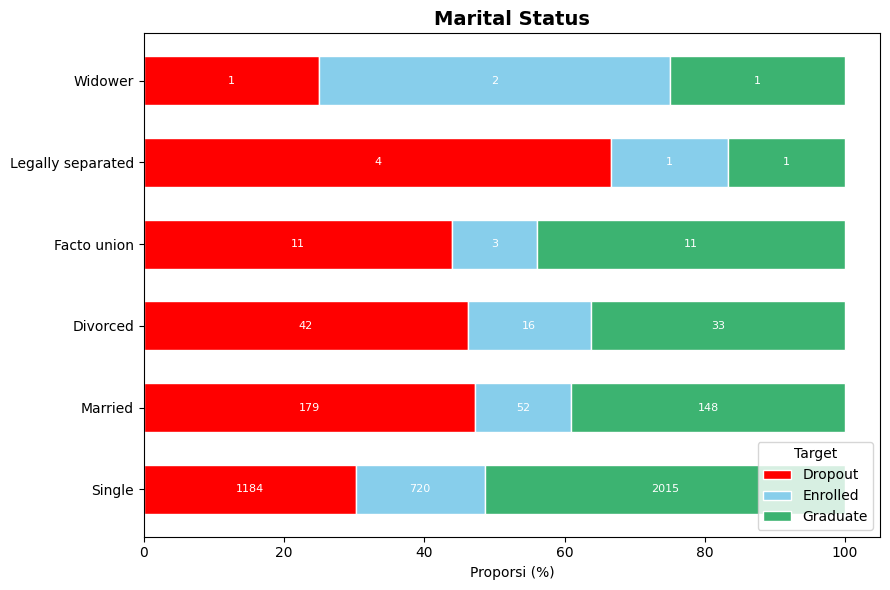

In [ ]:
interpretasi_kategorik(df_eda, 'Marital status', 'Marital Status')

Status pernikahan mencerminkan kondisi personal mahasiswa di luar akademik. Mahasiswa yang sudah menikah atau mengalami perpisahan kemungkinan memiliki tanggungan dan tekanan hidup yang lebih besar dibanding mahasiswa Single, sehingga lebih rentan dropout. Secara operasional, informasi status pernikahan bisa digunakan sebagai konteks tambahan saat konselor melakukan pendekatan personal kepada mahasiswa berisiko, misalnya menyediakan program khusus untuk mahasiswa yang sudah berkeluarga seperti kelas malam atau sistem pembelajaran yang lebih fleksibel.

****

**2. Application Mode**

Contingency Table:
Target                                        Dropout  Enrolled  Graduate
Application mode                                                         
1st Phase - General Contingent                    345       300      1063
1st Phase - Special Contingent (Azores)             2         8         6
1st Phase - Special Contingent (Madeira)            5         8        25
2nd Phase - General Contingent                    256       159       457
3rd Phase - General Contingent                     45        16        63
Change of Course                                  115        75       122
Change of Institution/Course                       20        13        26
Change of Institution/Course (International)        0         0         1
Holders of Other Higher Courses                    85         7        47
International Student (Bachelor)                    5        10        15
Ordinance No. 533-A/99 item b2                      1         0         0
Ordinance No. 533-A

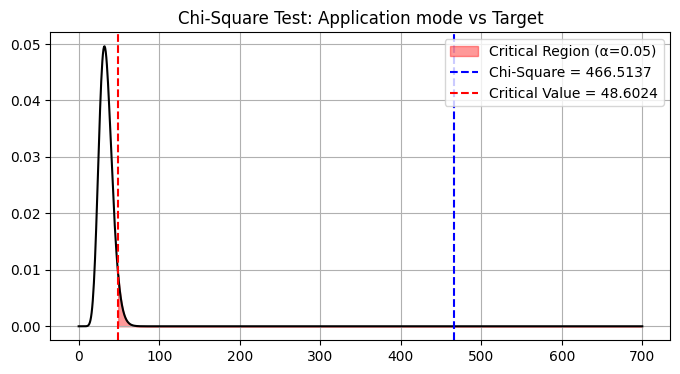

Bias-Corrected Cramér's V : 0.2211 → Strong


In [ ]:
chi_square_test(df_eda, 'Application mode', 'Target', alpha=0.05)

Chi-Square = 466.51 jauh melampaui nilai kritis 48.60 dengan p-value < 0.001. Cramér's V = 0.2211 menunjukkan hubungan yang strong antara jalur pendaftaran dan dropout.

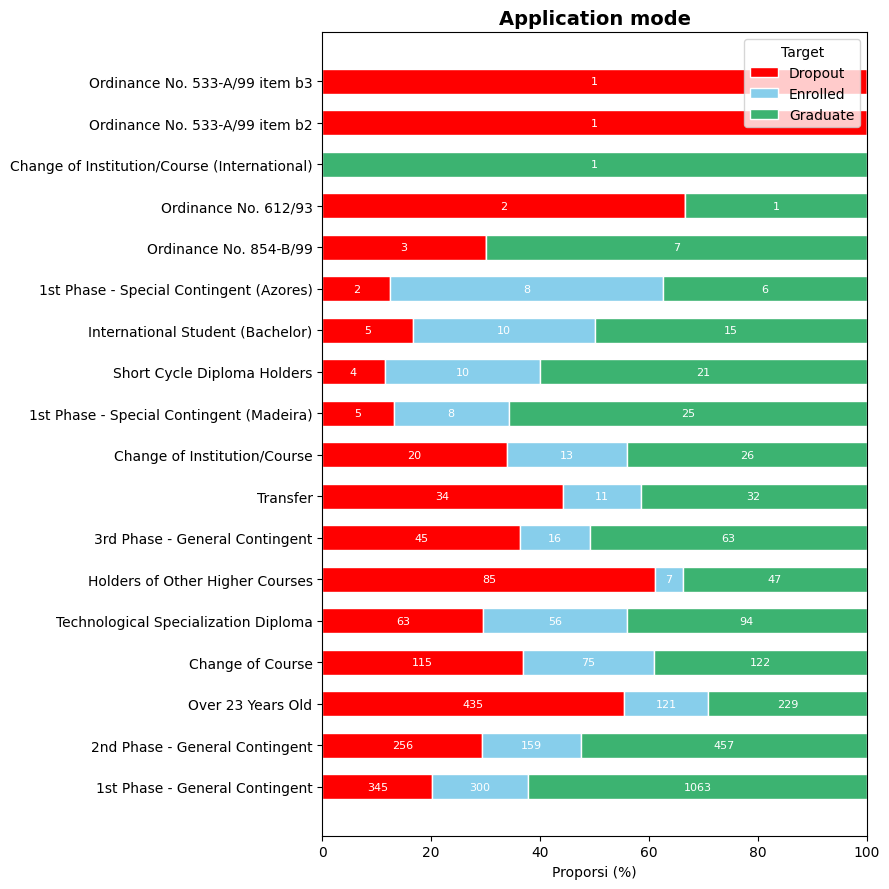

In [ ]:
interpretasi_kategorik(df_eda, 'Application mode', 'Application mode')

Jalur pendaftaran dengan proporsi Dropout tertinggi adalah Over 23 Years Old (55%), diikuti Holders of Other Higher Courses (61%) dan Transfer (44%). Sebaliknya, 1st Phase - General Contingent memiliki proporsi Graduate tertinggi (62%) dan merupakan jalur dengan jumlah mahasiswa terbanyak (1.708 orang).

Jalur masuk mencerminkan latar belakang dan motivasi mahasiswa yang sangat berbeda-beda. Mahasiswa yang masuk melalui jalur usia di atas 23 tahun kemungkinan memiliki beban tambahan seperti pekerjaan dan tanggung jawab keluarga yang meningkatkan risiko dropout. Mahasiswa dari jalur reguler (1st Phase) yang sudah mempersiapkan diri sejak SMA cenderung lebih siap secara akademik maupun mental. Institusi perlu merancang program dukungan khusus berdasarkan jalur masuk mahasiswa.



---



**3. Application order	**

Contingency Table:
Target             Dropout  Enrolled  Graduate
Application order                             
1st Choice               0         0         1
2nd Choice            1053       565      1408
3rd Choice             150        96       301
4th Choice              76        60       173
5th Choice              58        31       160
6th Choice              53        25        76
7th Choice              31        16        90
Last Choice              0         1         0

Chi-Square : 69.6087
P-Value    : < 0.001
Df         : 14
Nilai Kritis (α=0.05): 23.6848
Keputusan  : Tolak H0 → Dependen


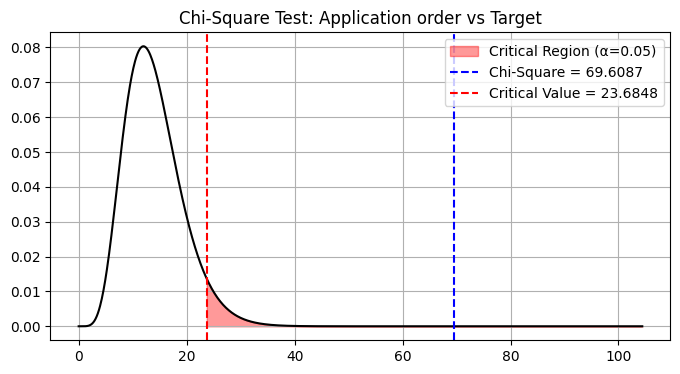

Bias-Corrected Cramér's V : 0.0793 → Weak


In [ ]:
chi_square_test(df_eda, 'Application order', 'Target', alpha=0.05)

Chi-Square = 69.61 melampaui nilai kritis 23.68 dengan p-value < 0.001. Cramér's V = 0.0793 menunjukkan hubungan yang weak antara urutan pilihan prodi dan dropout.

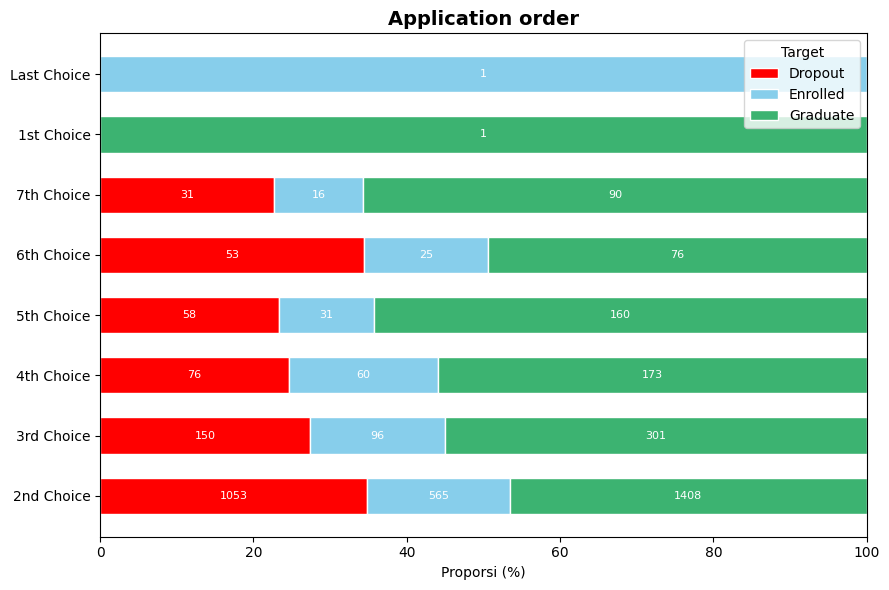

In [ ]:
interpretasi_kategorik(df_eda, 'Application order', 'Application order')

Sebagian besar mahasiswa (3.026 orang) memilih prodi ini sebagai pilihan ke-2 (2nd Choice), dengan proporsi Dropout 35% dan Graduate 47%. Mahasiswa dengan pilihan ke-5 dan ke-7 justru memiliki proporsi Graduate lebih tinggi (64% dan 66%), kemungkinan karena mereka lebih realistis dalam memilih prodi yang sesuai kemampuan.

Meskipun terbukti signifikan secara statistik, kekuatan hubungannya lemah. Urutan pilihan prodi bisa menjadi proxy motivasi — mahasiswa yang memasukkan prodi sebagai pilihan utama belum tentu lebih termotivasi, bisa jadi karena tekanan eksternal atau ikut-ikutan. Fitur ini tetap berguna sebagai konteks tambahan dalam model namun bukan prediktor kuat.



---



**4. Course**

Contingency Table:
Target                                Dropout  Enrolled  Graduate
Course                                                           
Advertising and Marketing Management       95        48       125
Agronomy                                   86        37        87
Animation and Multimedia Design            82        37        96
Basic Education                            85        50        57
Biofuel Production Technologies             8         3         1
Communication Design                       51        42       133
Equinculture                               78        21        42
Informatics Engineering                    92        64        14
Journalism and Communication              101        34       196
Management                                134       108       138
Management (Evening)                      136        54        78
Nursing                                   118       100       548
Oral Hygiene                               33        17  

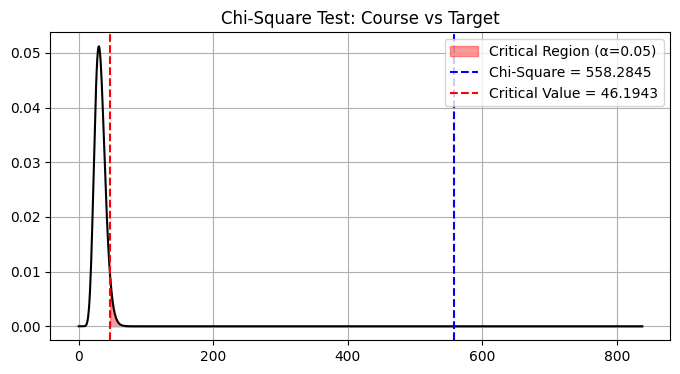

Bias-Corrected Cramér's V : 0.2439 → Strong


In [ ]:
chi_square_test(df_eda, 'Course', 'Target', alpha=0.05)

Chi-Square = 558.28 jauh melampaui nilai kritis 46.19 dengan p-value < 0.001. Cramér's V = 0.244 menunjukkan hubungan yang strong antara jurusan dan dropout.

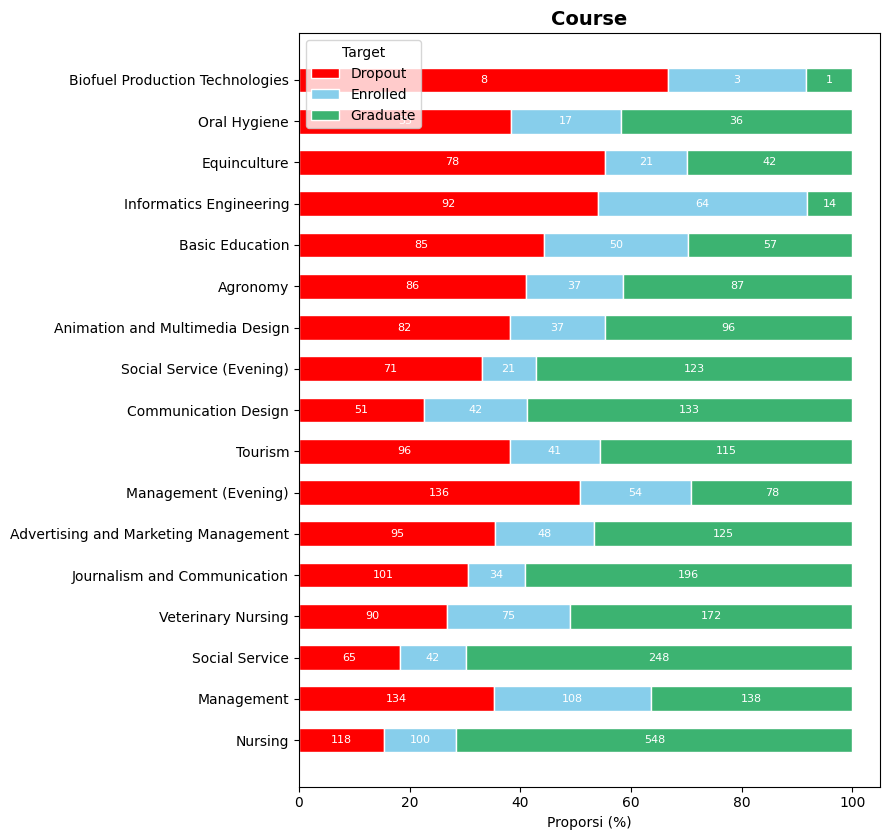

In [ ]:
interpretasi_kategorik(df_eda, 'Course', 'Course')

Proporsi Dropout sangat bervariasi antar jurusan. Biofuel Production Technologies memiliki proporsi Dropout tertinggi (67%) disusul Informatics Engineering (54%) dan Equinculture (55%). Sebaliknya, Nursing memiliki proporsi Graduate tertinggi (~72%) diikuti Social Service (70%) dan Journalism and Communication (59%).

Jurusan tertentu secara konsisten menghasilkan dropout yang lebih tinggi, mengindikasikan bahwa tingkat kesulitan kurikulum, beban studi, atau prospek karir jurusan berpengaruh terhadap keputusan mahasiswa untuk bertahan. Jurusan seperti Biofuel dan Informatics Engineering perlu mendapat perhatian khusus karena proporsi dropout-nya sangat tinggi. Secara operasional, institusi bisa merancang program pendampingan akademik yang spesifik per jurusan — bukan program generik — karena tantangan yang dihadapi mahasiswa tiap jurusan berbeda.

**5. Daytime/evening attendance**

Contingency Table:
Target                      Dropout  Enrolled  Graduate
Daytime/evening attendance                             
Daytime                        1214       719      2008
Evening                         207        75       201

Chi-Square : 28.7399
P-Value    : < 0.001
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Tolak H0 → Dependen


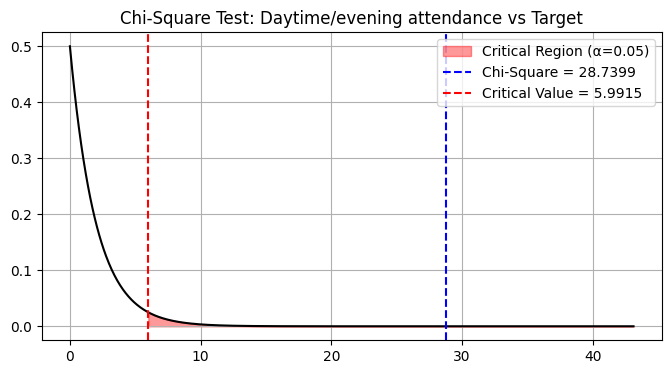

Bias-Corrected Cramér's V : 0.0778 → Weak


In [ ]:
chi_square_test(df_eda, 'Daytime/evening attendance', 'Target', alpha=0.05)

Chi-Square = 28.74 melampaui nilai kritis 5.99 dengan p-value < 0.001. Cramér's V = 0.0778 menunjukkan hubungan yang weak antara waktu kuliah dan dropout.

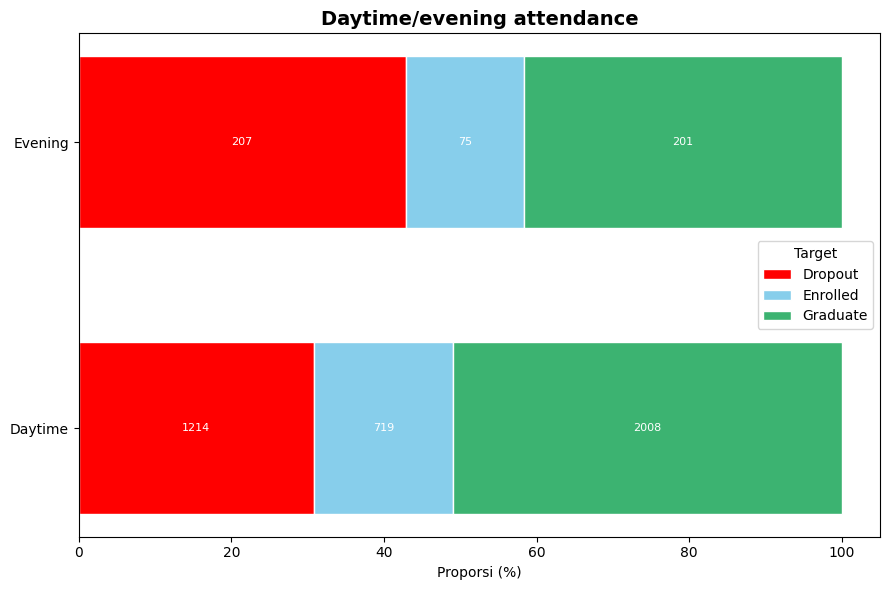

In [ ]:
interpretasi_kategorik(df_eda, 'Daytime/evening attendance', 'Daytime/evening attendance')

Mayoritas mahasiswa kuliah siang (Daytime) sebanyak 3.941 orang dengan proporsi Graduate 51% dan Dropout 31%. Mahasiswa kelas malam (Evening) yang berjumlah 483 orang memiliki proporsi Dropout lebih tinggi (43%) dan Graduate lebih rendah (42%).

Meskipun kekuatan hubungannya lemah, perbedaan proporsi ini konsisten dengan asumsi bahwa mahasiswa kelas malam umumnya merangkap bekerja. Beban ganda antara pekerjaan dan kuliah meningkatkan risiko dropout karena waktu belajar yang terbatas dan kelelahan fisik. Fitur ini berguna sebagai sinyal konteks tambahan dalam model prediksi.



---



**6. Previous qualification**

Contingency Table:
Target                                 Dropout  Enrolled  Graduate
Previous qualification                                            
10th Year                                    1         0         0
10th Year - Not Completed                    1         0         1
11th Year - Not Completed                    3         0         1
12th Year - Not Completed                   11         0         0
Basic Education 2nd Cycle                    3         1         3
Basic Education 3rd Cycle                  104        13        45
Frequency of Higher Education                7         1         8
Higher Education - Bachelor's Degree        16         1         6
Higher Education - Degree                   75         4        47
Higher Education - Degree (1st Cycle)       14         6        20
Higher Education - Doctorate                 1         0         0
Higher Education - Master (2nd Cycle)        2         0         4
Higher Education - Master's                

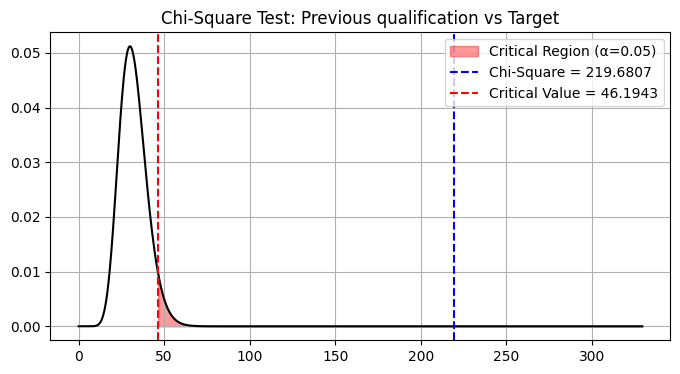

Bias-Corrected Cramér's V : 0.1457 → Moderate


In [ ]:
chi_square_test(df_eda, 'Previous qualification', 'Target', alpha=0.05)

Chi-Square = 219.68 jauh melampaui nilai kritis 46.19 dengan p-value < 0.001. Cramér's V = 0.1457 menunjukkan hubungan yang moderate antara kualifikasi pendidikan sebelumnya dan dropout.

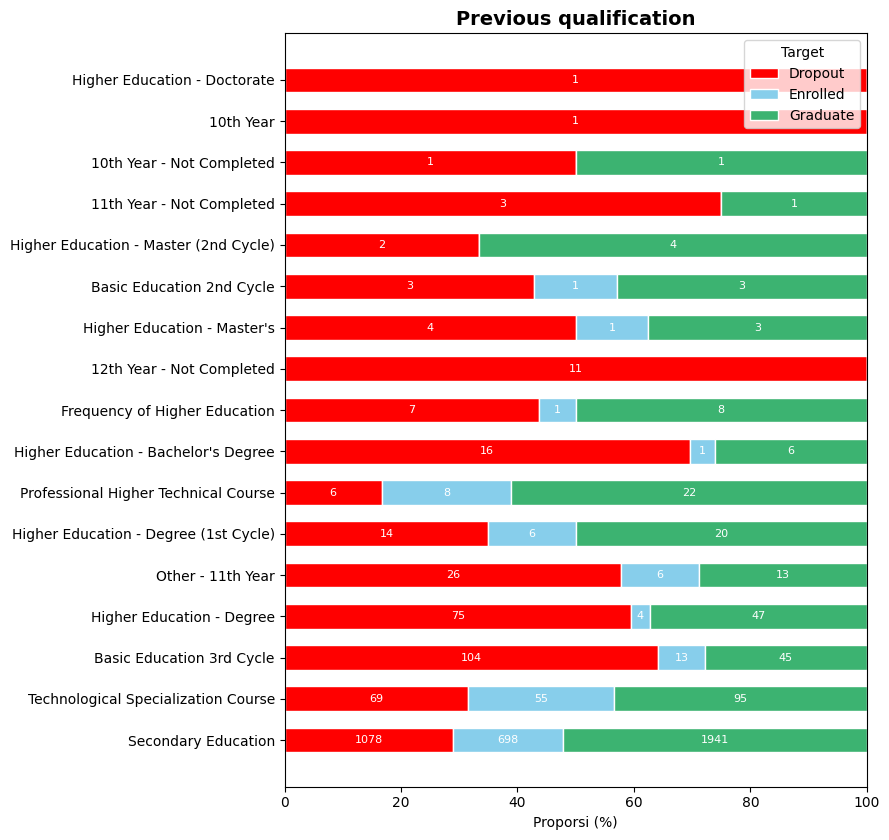

In [ ]:
interpretasi_kategorik(df_eda, 'Previous qualification', 'Previous qualification')

Mayoritas mahasiswa masuk dengan ijazah Secondary Education (3.717 orang) dengan proporsi Graduate 52% dan Dropout 29%. Mahasiswa yang sebelumnya menempuh Higher Education - Degree memiliki proporsi Dropout cukup tinggi (60%), kemungkinan karena mereka mencoba peruntungan di bidang baru yang tidak sesuai. Sebaliknya, Professional Higher Technical Course dan Technological Specialization Course memiliki proporsi Graduate yang relatif baik.

Latar belakang pendidikan sebelumnya mencerminkan kesiapan akademik awal mahasiswa. Mahasiswa yang masuk dengan dasar pendidikan tidak selesai (misalnya 12th Year Not Completed) hampir semuanya berakhir Dropout, meskipun jumlah sampelnya kecil. Fitur ini relevan sebagai indikator kesiapan awal dan layak dipertahankan dalam model.



---



**7. Nacionality**

Contingency Table:
Target        Dropout  Enrolled  Graduate
Nacionality                              
Angolan             1         1         0
Brazilian          14         6        18
Cape Verdean        4         1         8
Colombian           1         0         0
Cuban               0         1         0
Dutch               0         0         1
English             0         0         1
German              0         0         2
Guinean             1         0         4
Italian             0         0         3
Lithuanian          1         0         0
Mexican             1         0         1
Moldovan            2         1         0
Mozambican          0         1         1
Portuguese       1389       770      2155
Romanian            0         1         1
Russian             1         1         0
Santomean           1         5         8
Spanish             4         5         4
Turkish             0         1         0
Ukrainian           1         0         2

Chi-Square : 4

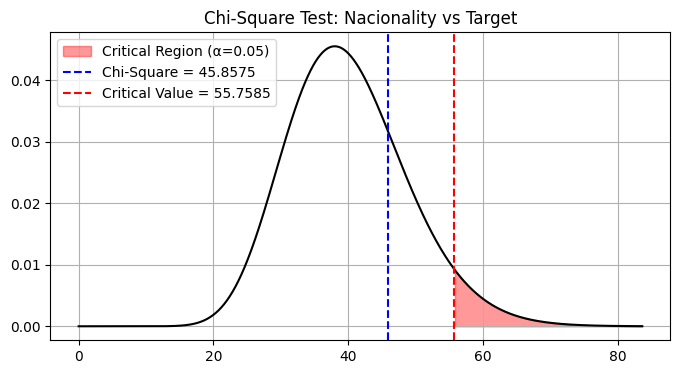

Bias-Corrected Cramér's V : 0.0257 → No or very weak


In [ ]:
chi_square_test(df_eda, 'Nacionality', 'Target', alpha=0.05)

Uji Chi-Square
Chi-Square = 45.86 di bawah nilai kritis 55.76 dengan p-value = 0.242 (> 0.05), artinya Terima H0 — tidak ada hubungan yang signifikan antara nasionalitas dan dropout.

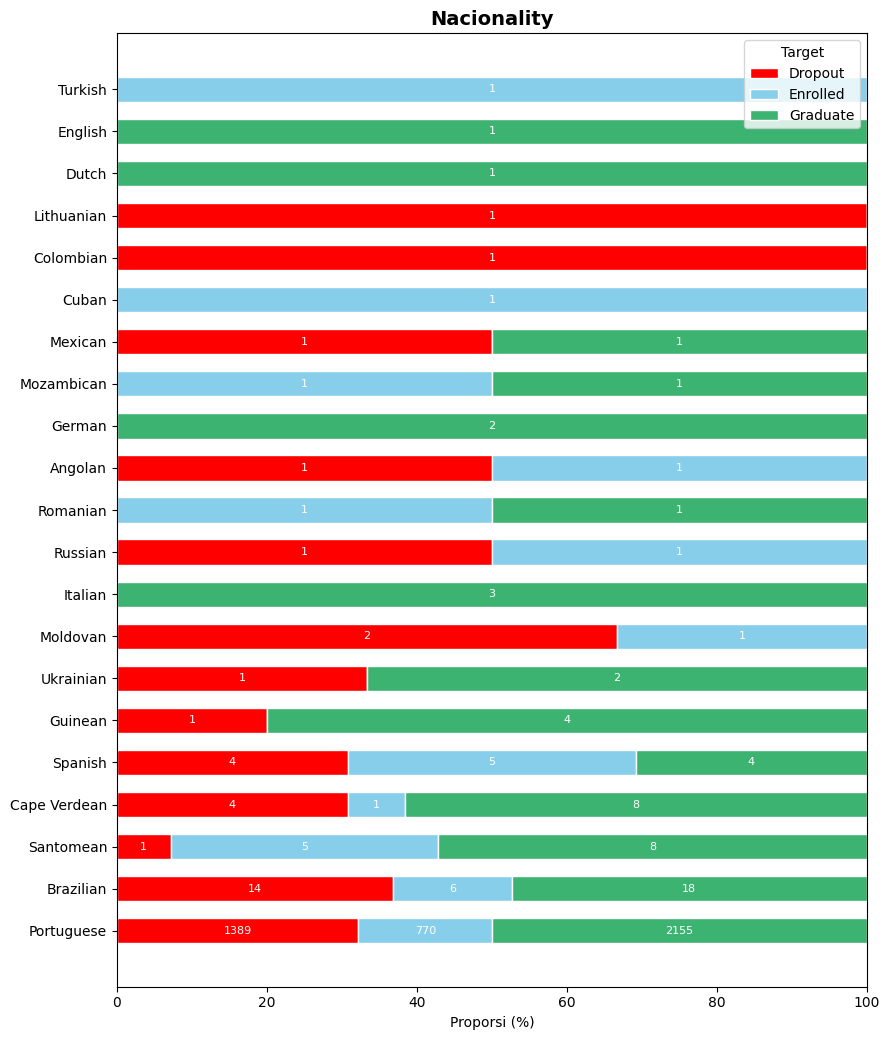

In [ ]:
interpretasi_kategorik(df_eda, 'Nacionality', 'Nacionality')

Nasionalitas tidak terbukti berpengaruh terhadap dropout, didukung Cramér's V = 0.026 yang menunjukkan hubungan hampir tidak ada. Selain itu sebagian besar kategori nasionalitas memiliki sampel yang sangat kecil (1-2 mahasiswa) sehingga tidak representatif untuk dianalisis. Mayoritas data didominasi Portuguese (1389 Dropout, 770 Enrolled, 2155 Graduate) yang proporsinya (~32% Dropout) mirip dengan rata-rata keseluruhan dataset. Kesimpulannya, nasionalitas bukan faktor yang perlu dimasukkan ke dalam model prediksi dropout

**8. Mother's qualification**

Contingency Table:
Target                                              Dropout  Enrolled  \
Mother's qualification                                                  
10th Year of Schooling                                    1         0   
11th Year of Schooling - Not Completed                    2         0   
12th Year of Schooling- Not Completed                     5         0   
2nd Cycle of the General High School Course               1         0   
7th Year (Old)                                            2         0   
7th Year of Schooling                                     0         0   
8th Year of Schooling                                     1         0   
9th Year - Not Completed                                  1         0   
Basic Education 1st Cycle (4th/5th year) or equiv.      383       169   
Basic Education 2nd Cycle (6th/7th/8th Year) or...      140        91   
Basic Education 3rd Cycle (9th/10th/11th Year) ...      271       176   
Can Read Without having a 4th ye

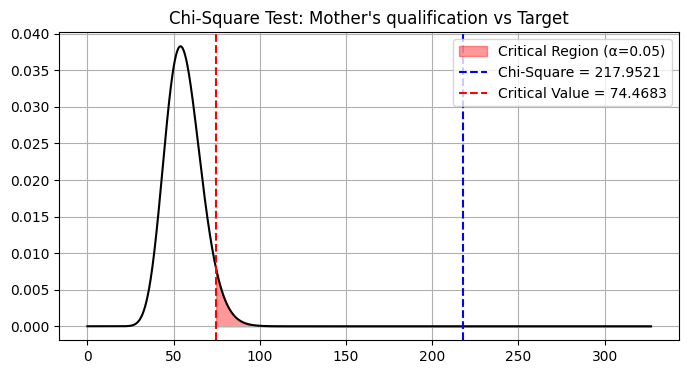

Bias-Corrected Cramér's V : 0.1353 → Moderate


In [ ]:
chi_square_test(df_eda, "Mother's qualification", 'Target', alpha=0.05)

Chi-Square = 217.95 jauh melampaui nilai kritis 74.47 dengan p-value < 0.001. Cramér's V = 0.1353 menunjukkan hubungan yang moderate antara tingkat pendidikan ibu dan dropout.

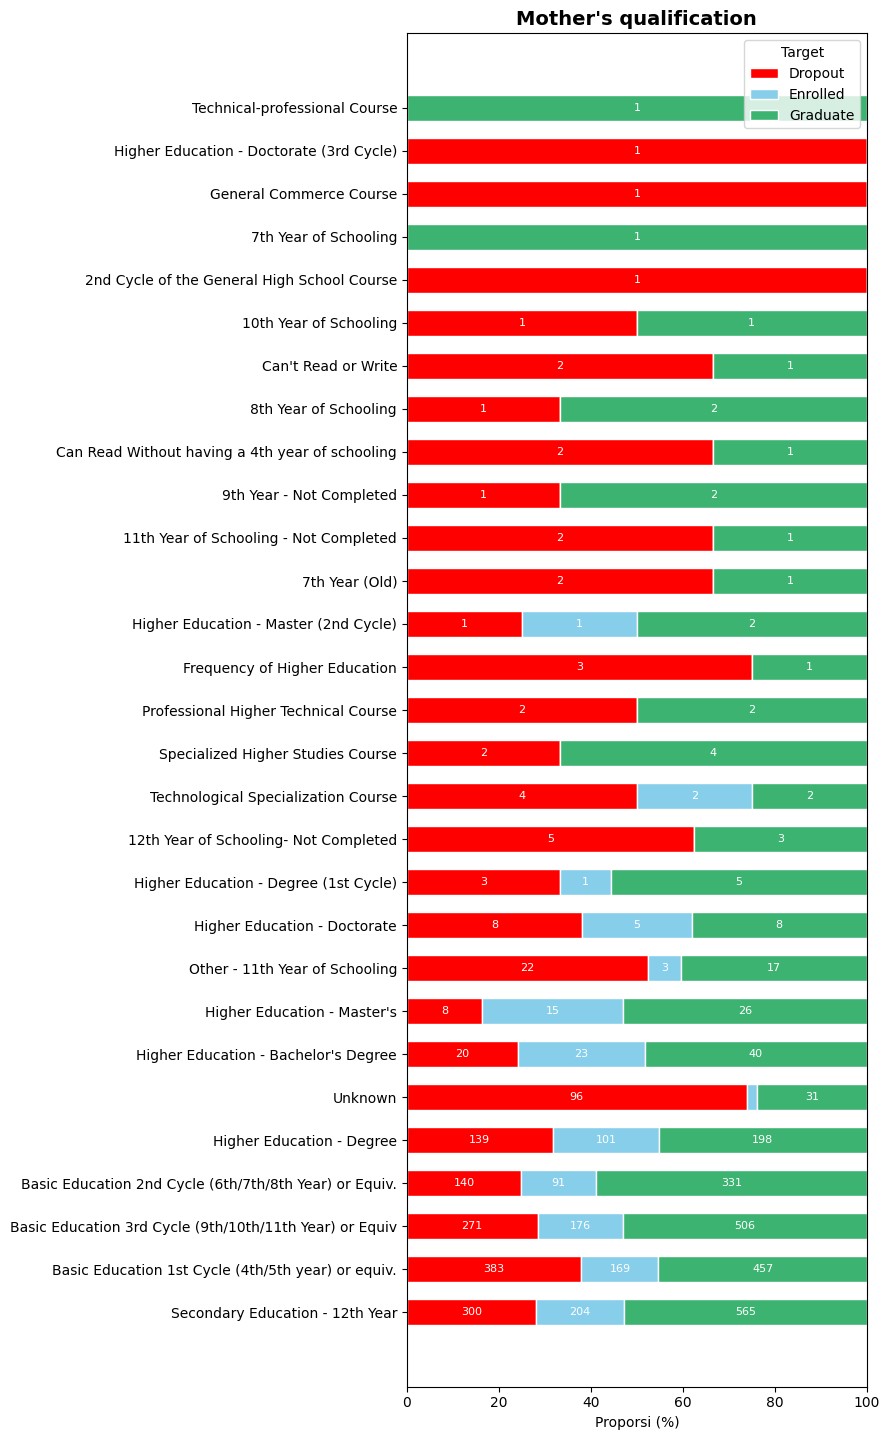

In [ ]:
interpretasi_kategorik(df_eda, "Mother's qualification", "Mother's qualification")

Pendidikan ibu yang paling umum adalah Basic Education 1st Cycle (1.009 orang) dan Basic Education 3rd Cycle (953 orang). Ibu dengan pendidikan Higher Education - Master's memiliki proporsi Graduate anak tertinggi (53%) dan Dropout terendah (16%). Sebaliknya, kategori Unknown memiliki proporsi Dropout sangat tinggi (74%), kemungkinan menandakan keterbatasan data sosio-ekonomi keluarga.

Semakin tinggi pendidikan ibu, semakin besar kemungkinan anaknya lulus kuliah. Ini mencerminkan transfer modal akademis dan sosial dari orang tua — ibu berpendidikan tinggi lebih mampu membimbing dan mendukung anak secara akademik. Fitur ini berguna sebagai indikator latar belakang sosio-ekonomi keluarga dalam model.



---



**9. Father's qualification**

Contingency Table:
Target                                              Dropout  Enrolled  \
Father's qualification                                                  
10th Year of Schooling                                    1         0   
11th Year of Schooling - Not Completed                    2         0   
12th Year of Schooling - Not Completed                    1         0   
2nd Cycle General High School Course                      1         0   
2nd Year Complementary High School Course                 1         0   
7th Year (Old)                                            4         0   
7th Year of Schooling                                     1         0   
8th Year of Schooling                                     1         1   
9th Year of Schooling - Not Completed                     3         0   
Basic Education 1st Cycle (4th/5th year) or equiv.      432       199   
Basic Education 2nd Cycle (6th/7th/8th Year) or...      167       127   
Basic Education 3rd Cycle (9th/1

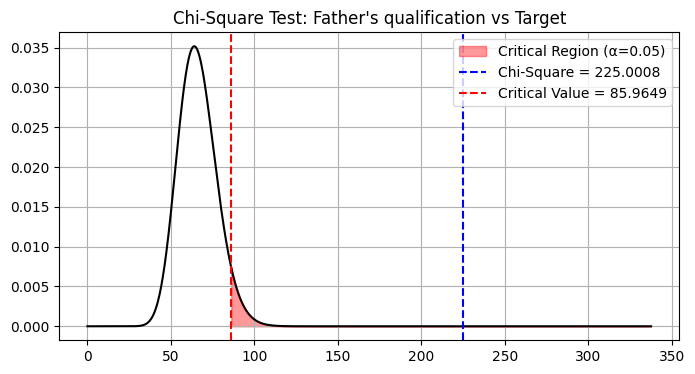

Bias-Corrected Cramér's V : 0.1341 → Moderate


In [ ]:
chi_square_test(df_eda, "Father's qualification", 'Target', alpha=0.05)

Chi-Square = 214.59 jauh melampaui nilai kritis 74.47 dengan p-value < 0.001. Cramér's V = 0.1340 menunjukkan hubungan yang moderate antara tingkat pendidikan ayah dan dropout.

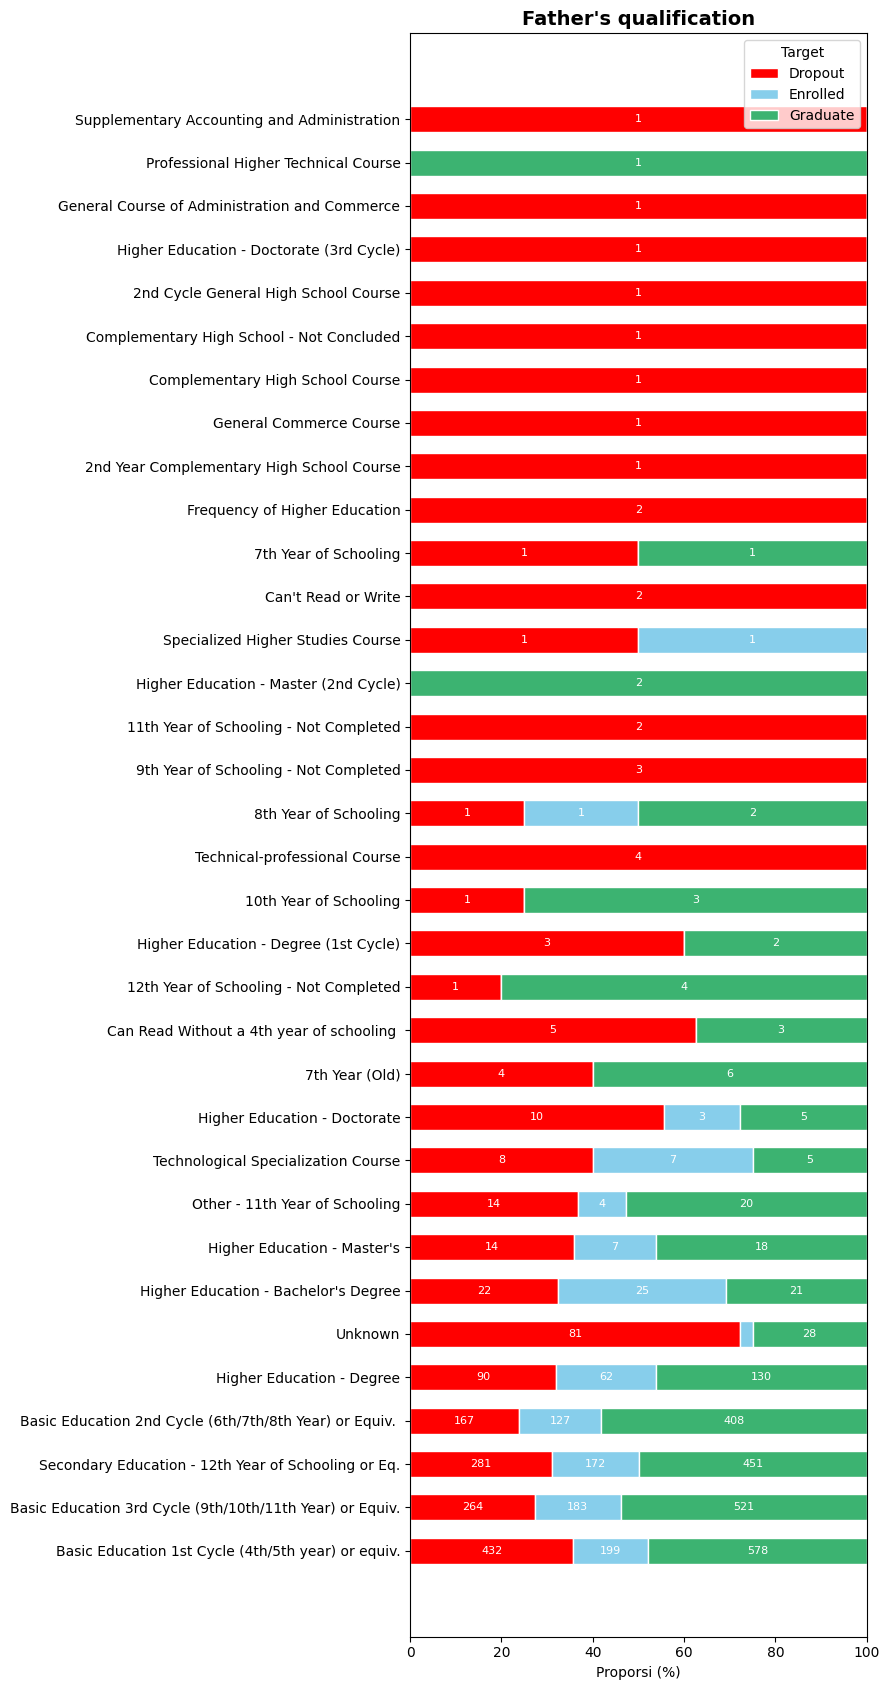

In [ ]:
interpretasi_kategorik(df_eda, "Father's qualification", "Father's qualification")

Pola yang ditemukan sangat konsisten dengan pendidikan ibu. Basic Education 1st Cycle (1.209 orang) dan Basic Education 3rd Cycle (968 orang) mendominasi distribusi. Kategori Unknown kembali menunjukkan proporsi Dropout sangat tinggi (72%), konsisten dengan temuan pada pendidikan ibu. Ayah dengan pendidikan Higher Education - Master's memiliki proporsi Graduate anak yang baik (46%).

Pendidikan ayah dan ibu bersama-sama membentuk gambaran lingkungan belajar di rumah. Keduanya berkontribusi sebagai proxy status sosio-ekonomi keluarga yang berpengaruh terhadap keberhasilan akademik mahasiswa. Kedua fitur ini saling melengkapi dan keduanya layak dipertahankan dalam model.



---



**10. Mother's occupation**

Contingency Table:
Target                                              Dropout  Enrolled  \
Mother's occupation                                                     
Administrative Staff                                    248       147   
Armed Forces Professions                                  1         2   
Blank                                                    13         2   
Cleaning Workers                                          0        11   
Data, Accounting, Statistical, Financial Servic...        0         2   
Farmers and Skilled Workers in Agriculture, Fis...       26        14   
Health Professionals                                      0         2   
Installation and Machine Operators and Assembly...       15         7   
Intermediate Level Science & Engineering Techni...        0         1   
Intermediate Level Technicians and Professions           95        79   
Intermediate Level Technicians from Legal, Soci...        1         2   
Legislative and Executive Bodies

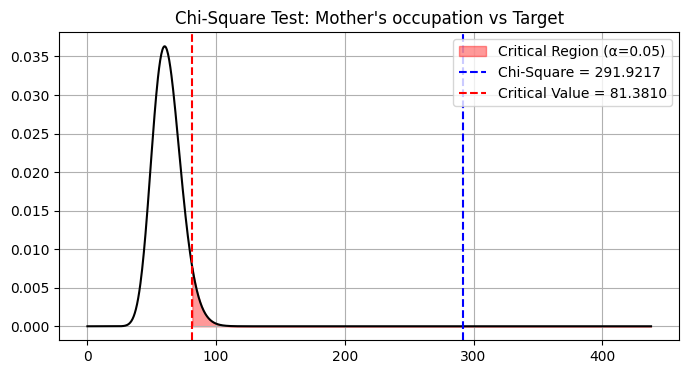

Bias-Corrected Cramér's V : 0.1612 → Strong


In [ ]:
chi_square_test(df_eda, "Mother's occupation", 'Target', alpha=0.05)

Chi-Square = 291.92 jauh melampaui nilai kritis 81.38 dengan p-value < 0.001. Cramér's V = 0.1612 menunjukkan hubungan yang strong antara pekerjaan ibu dan dropout.

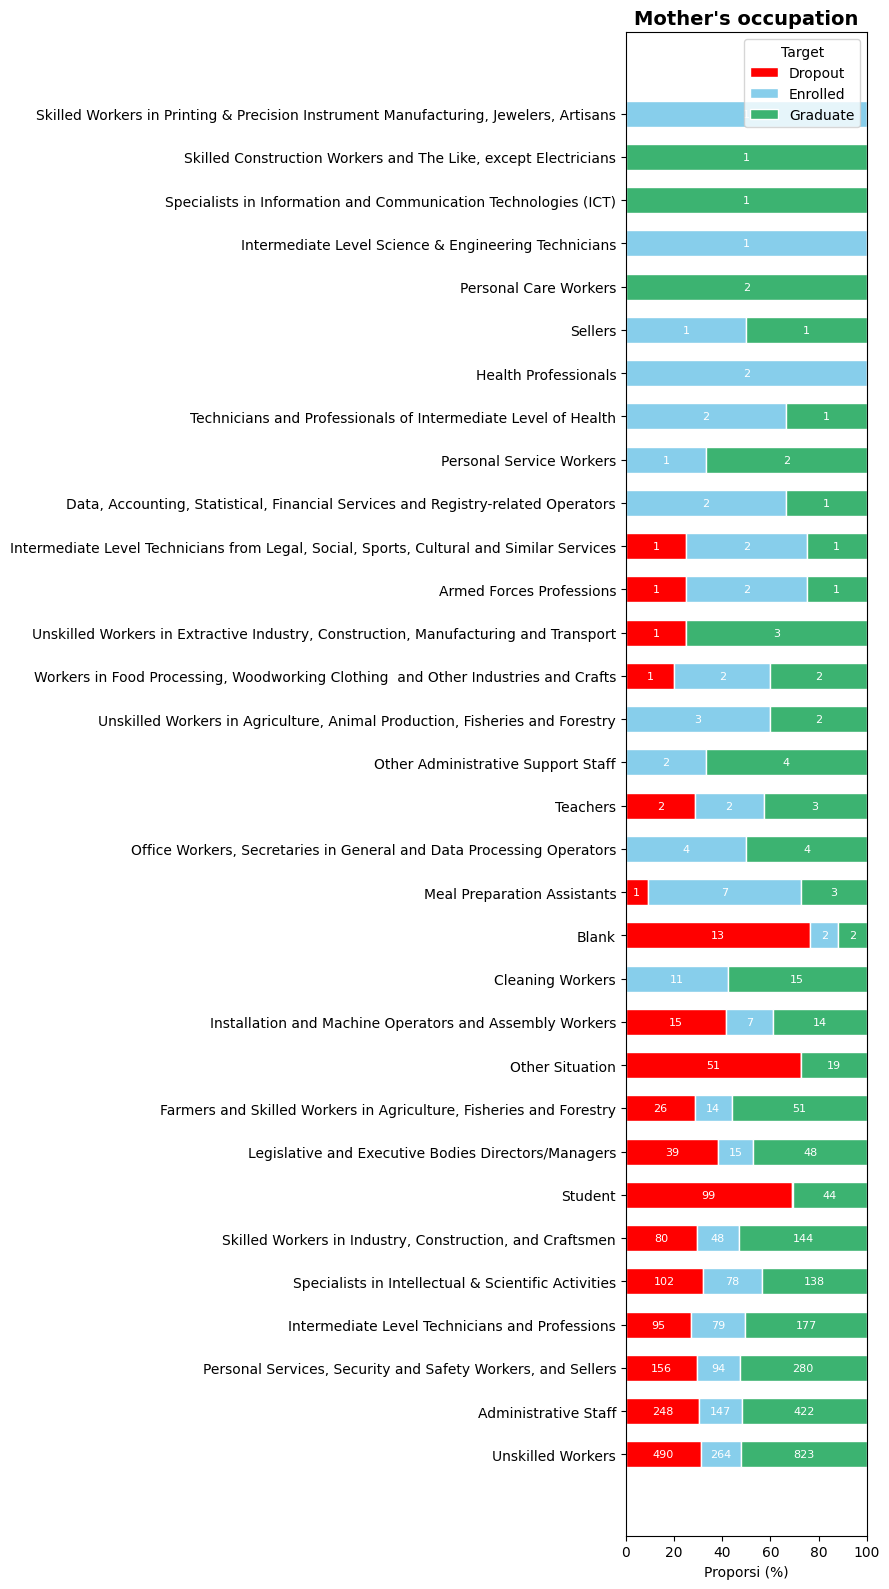

In [ ]:
interpretasi_kategorik(df_eda, "Mother's occupation", "Mother's occupation")

Pekerjaan ibu terbanyak adalah Unskilled Workers (1.577 orang) dengan proporsi Dropout 31%, diikuti Administrative Staff (817 orang) dengan Dropout 30%. Kategori Student (144 orang) — yang artinya ibu juga masih kuliah — memiliki proporsi Dropout anak tertinggi (69%), mengindikasikan kondisi keluarga yang tidak stabil secara finansial. Kategori Blank (17 orang) juga menunjukkan Dropout tinggi (77%).

Pekerjaan ibu di sektor profesional berkorelasi dengan tingkat Graduate anak yang lebih tinggi, mencerminkan stabilitas ekonomi dan dukungan keluarga yang lebih baik. Pekerjaan ibu terbukti lebih kuat dari sekadar tingkat pendidikannya sebagai prediktor, karena langsung mencerminkan kondisi ekonomi keluarga. Fitur ini relevan dan lebih kuat dibanding Mother's Qualification dalam kontribusinya pada model.



---



**11. Father's occupation**

Contingency Table:
Target                                              Dropout  Enrolled  \
Father's occupation                                                     
Administrative Staff                                    139        74   
Armed Forces Officers                                     0         0   
Armed Forces Professions                                 85        54   
Armed Forces Sergeants                                    0         1   
Assembly Workers                                          0         1   
Blank                                                    13         2   
Data, Accounting, Statistical, Financial Servic...        0         0   
Directors of Administrative and Commercial Serv...        1         1   
Farmers and Skilled Workers in Agriculture, Fis...       69        48   
Farmers, Livestock Keepers, Fishermen, Hunters ...        0         3   
Finance, Accounting, Administrative Organizatio...        0         0   
Fixed Plant and Machine Operator

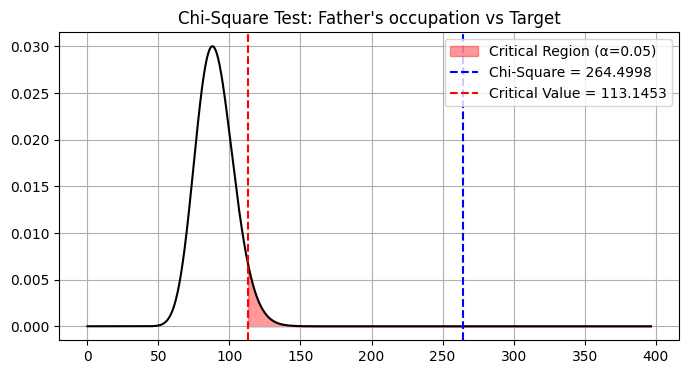

Bias-Corrected Cramér's V : 0.1405 → Moderate


In [ ]:
chi_square_test(df_eda, "Father's occupation", 'Target', alpha=0.05)

Chi-Square = 264.50 jauh melampaui nilai kritis 113.15 dengan p-value < 0.001. Cramér's V = 0.1405 menunjukkan hubungan yang moderate antara pekerjaan ayah dan dropout.

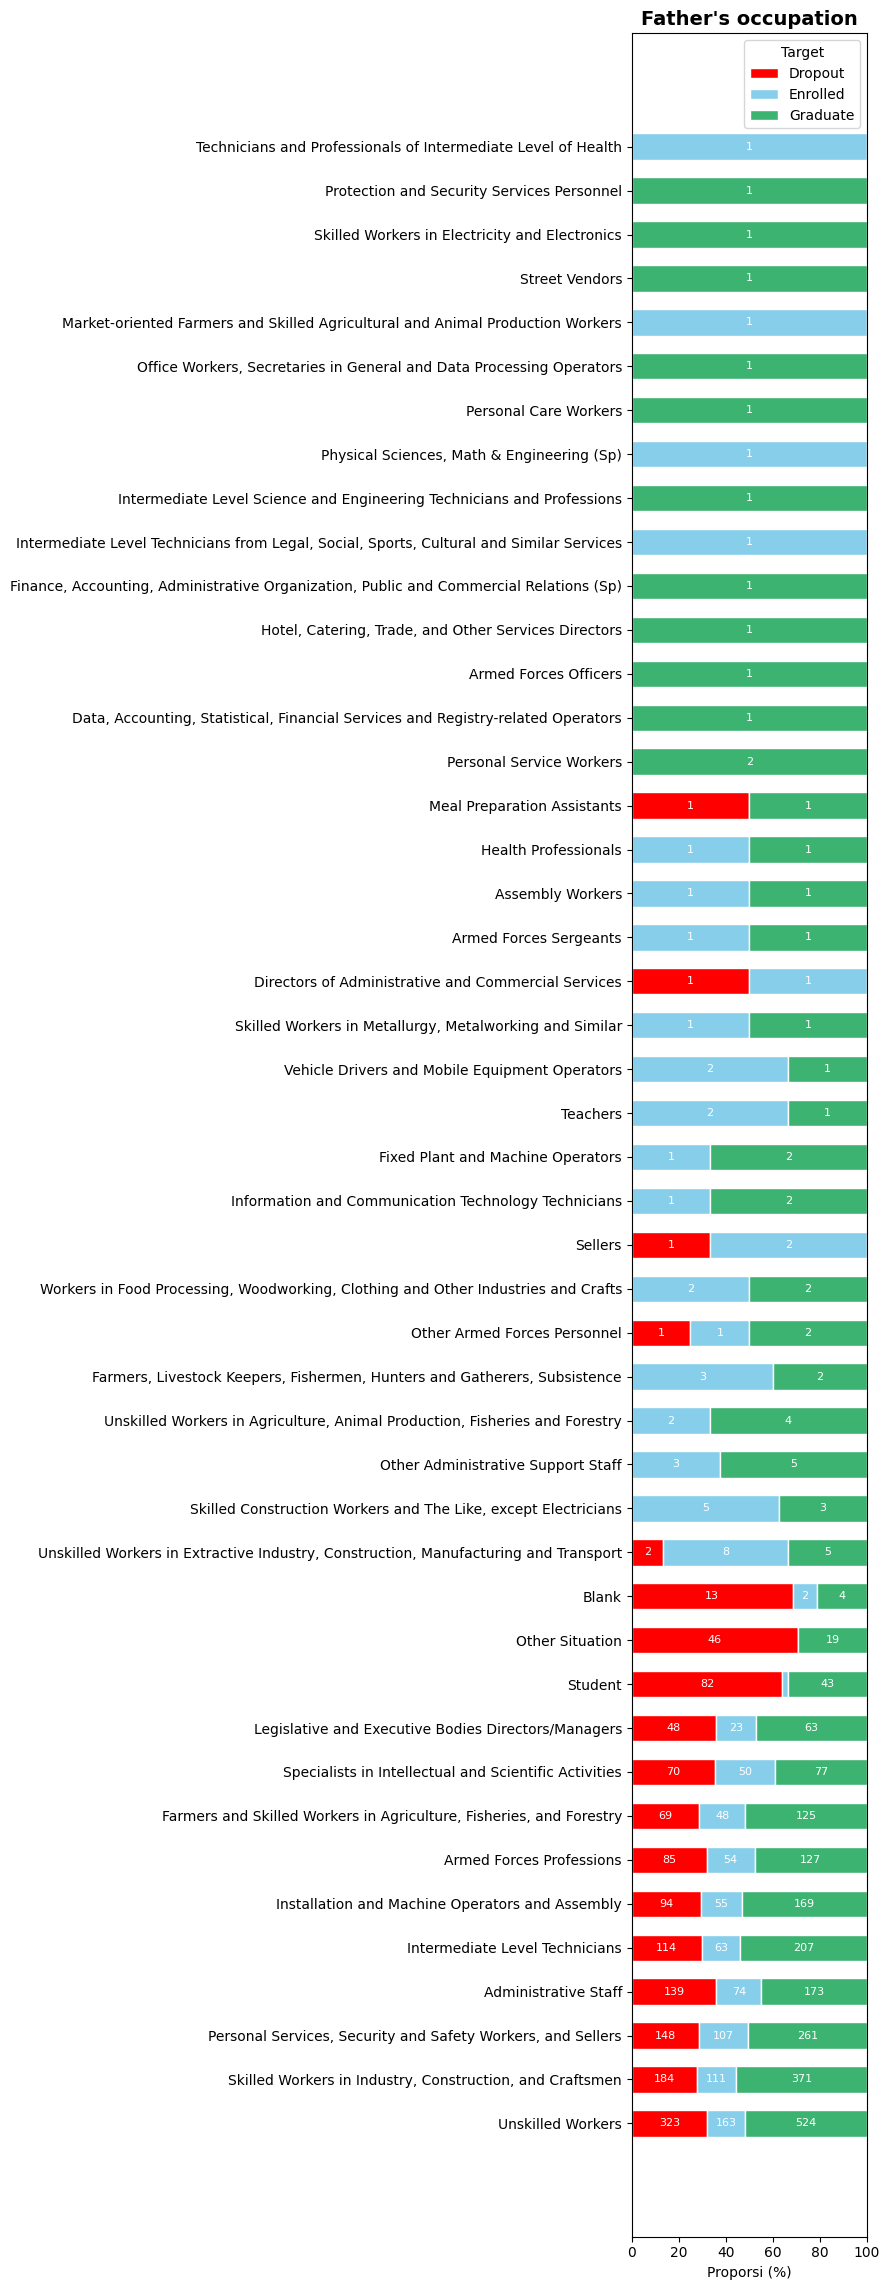

In [ ]:
interpretasi_kategorik(df_eda, "Father's occupation", "Father's occupation")

Unskilled Workers (1.010 orang) adalah pekerjaan ayah terbanyak dengan proporsi Dropout 32%. Kategori Student (128 orang) kembali menunjukkan proporsi Dropout anak tinggi (64%), konsisten dengan temuan pekerjaan ibu. Kategori Other dan Blank juga memiliki proporsi Dropout di atas 68%. Sebaliknya, ayah yang bekerja sebagai Skilled Workers (666 orang) memiliki proporsi Graduate anak yang baik (56%).

Tren yang ditemukan konsisten antara pekerjaan ayah dan ibu — pekerjaan di sektor informal atau tidak terampil dikaitkan dengan risiko dropout yang lebih tinggi. Kombinasi pekerjaan dan pendidikan kedua orang tua bersama-sama membentuk gambaran komprehensif kondisi sosio-ekonomi keluarga yang berpengaruh pada keberlangsungan studi mahasiswa.



---



**12. Displaced**

Contingency Table:
Target     Dropout  Enrolled  Graduate
Displaced                             
No             752       361       885
Yes            669       433      1324

Chi-Square : 57.7542
P-Value    : < 0.001
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Tolak H0 → Dependen


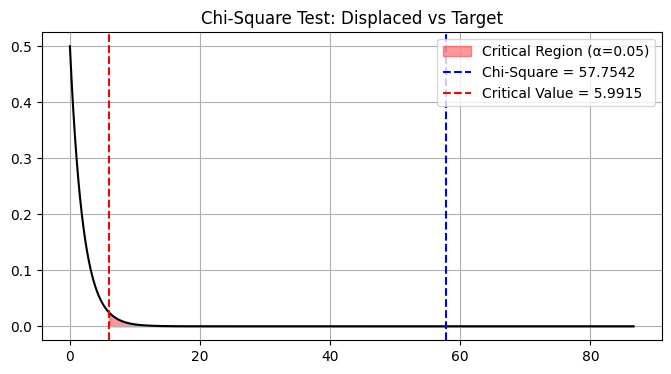

Bias-Corrected Cramér's V : 0.1123 → Moderate


In [ ]:
chi_square_test(df_eda, 'Displaced', 'Target', alpha=0.05)

Chi-Square = 57.75 jauh melampaui nilai kritis 5.99 dengan p-value < 0.001. Cramér's V = 0.1123 menunjukkan hubungan yang moderate antara status perpindahan domisili dan dropout.

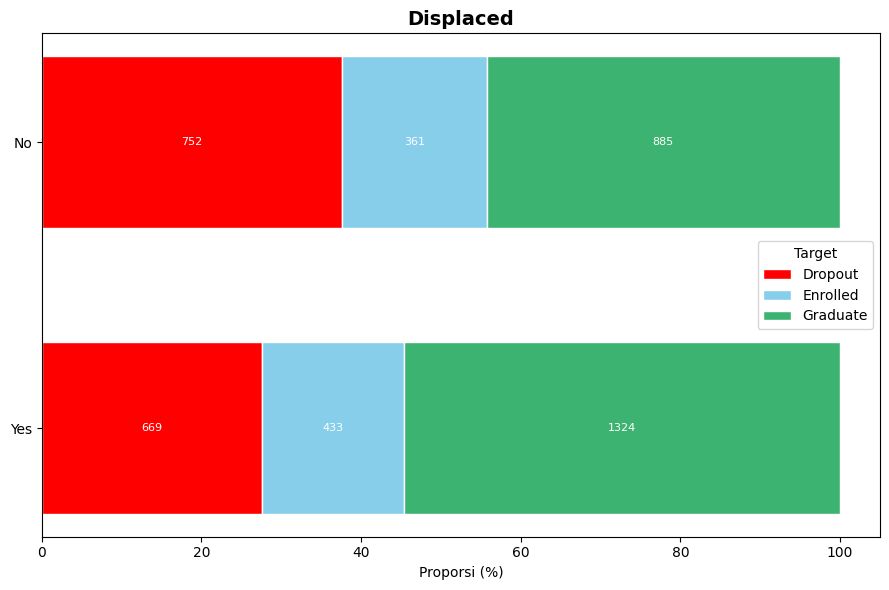

In [ ]:
interpretasi_kategorik(df_eda, "Displaced", "Displaced")

Mahasiswa yang pindah domisili (Yes) berjumlah 2.426 orang dengan proporsi Graduate justru lebih tinggi (55%) dan Dropout lebih rendah (28%) dibanding yang tidak pindah (No: Graduate 44%, Dropout 38%).

Temuan ini menarik karena berlawanan dari asumsi awal — mahasiswa yang pindah domisili ternyata lebih banyak yang lulus. Kemungkinan mereka adalah mahasiswa yang lebih termotivasi dan sudah mempersiapkan diri untuk kuliah jauh dari rumah. Meski begitu, hubungannya moderat dan fitur ini tetap relevan sebagai konteks demografis dalam model.



---



**13. Educational special needs**

Contingency Table:
Target                     Dropout  Enrolled  Graduate
Educational special needs                             
No                            1404       783      2186
Yes                             17        11        23

Chi-Square : 0.6421
P-Value    : 0.7254
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Terima H0 → Independen


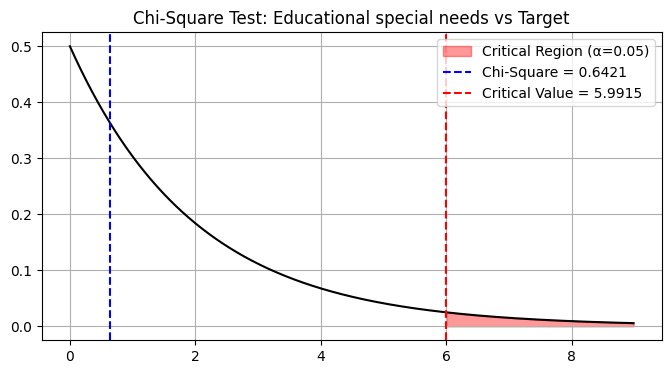

Bias-Corrected Cramér's V : 0.0000 → No or very weak


In [ ]:
chi_square_test(df_eda, 'Educational special needs', 'Target', alpha=0.05)


Chi-Square = 0.64 jauh di bawah nilai kritis 5.99 dengan p-value = 0.725, artinya Terima H0 — tidak ada hubungan antara kebutuhan pendidikan khusus dan dropout. Cramér's V = 0.000 mengkonfirmasi tidak ada hubungan sama sekali.

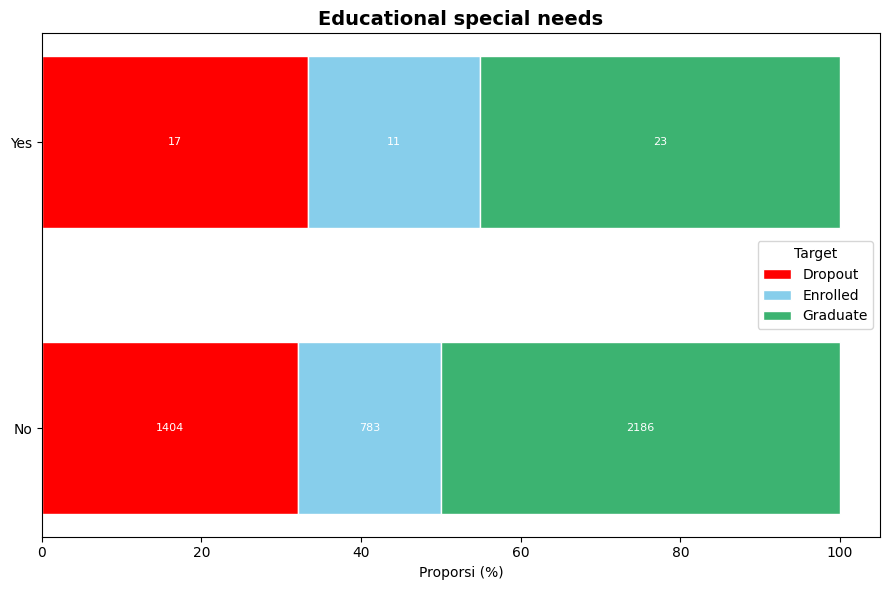

In [ ]:
interpretasi_kategorik(df_eda, 'Educational special needs', 'Educational special needs')

Proporsi Dropout antara mahasiswa dengan kebutuhan khusus (Yes) dan tanpa (No) hampir identik (~33% vs ~32%), yang menjelaskan mengapa uji statistiknya tidak signifikan. Selain itu jumlah sampel Yes sangat kecil (51 mahasiswa) dibanding No (4373 mahasiswa), sehingga tidak representatif. Fitur ini tidak perlu dimasukkan ke dalam model.

**14. Debtor**

Contingency Table:
Target  Dropout  Enrolled  Graduate
Debtor                             
No         1109       704      2108
Yes         312        90       101

Chi-Square : 259.3332
P-Value    : < 0.001
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Tolak H0 → Dependen


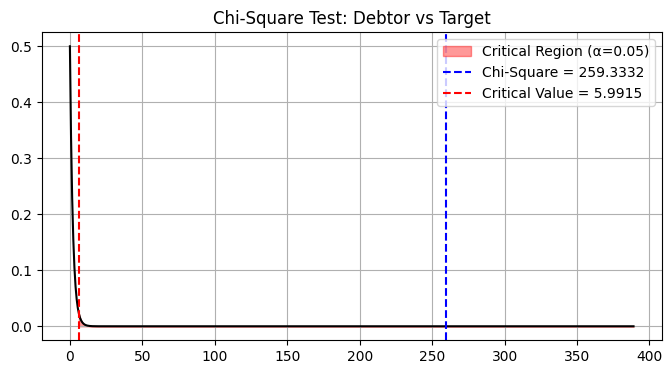

Bias-Corrected Cramér's V : 0.2412 → Strong


In [ ]:
chi_square_test(df_eda, 'Debtor', 'Target', alpha=0.05)

Chi-Square = 259.33 jauh melampaui nilai kritis 5.99 dengan p-value < 0.001. Cramér's V = 0.2412 menunjukkan hubungan yang strong antara status hutang dan dropout.

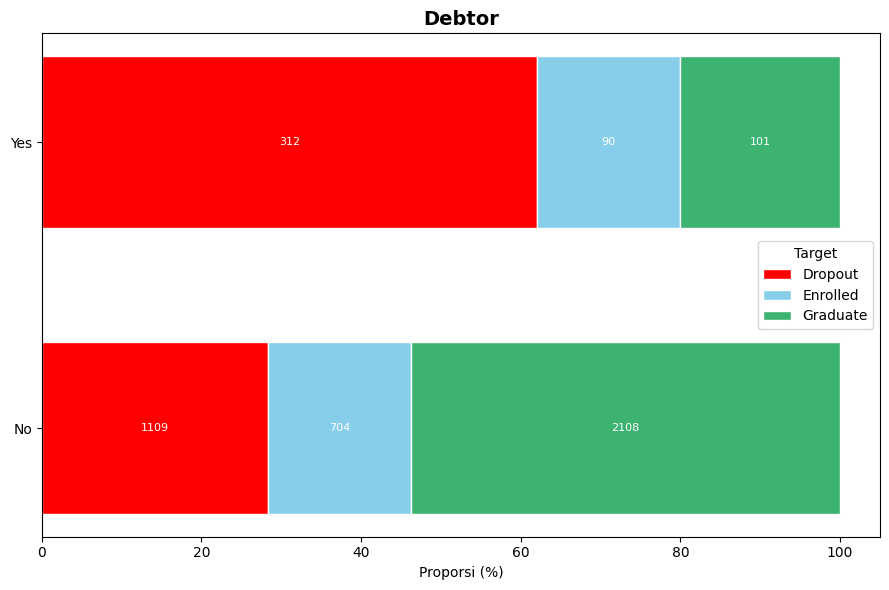

In [ ]:
interpretasi_kategorik(df_eda, 'Debtor', 'Debtor')

Mahasiswa berstatus Debtor (503 orang) didominasi Dropout dengan proporsi 62%, sementara Graduate hanya 20%. Sebaliknya, mahasiswa Non-Debtor (3.921 orang) memiliki proporsi Graduate 54% dan Dropout hanya 28%.

Hutang ke institusi adalah salah satu sinyal dropout paling kuat dalam dataset ini. Mahasiswa yang menunggak kemungkinan besar menghadapi hambatan administratif langsung — tidak bisa mengikuti ujian atau mengambil KRS — yang menciptakan lingkaran yang berujung pada dropout. Secara operasional, status Debtor bisa dijadikan trigger prioritas untuk intervensi finansial segera sebelum situasi mahasiswa memburuk.



---



**15. Tuition fees up to date**

Contingency Table:
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
No                           457        42        29
Yes                          964       752      2180

Chi-Square : 823.5527
P-Value    : < 0.001
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Tolak H0 → Dependen


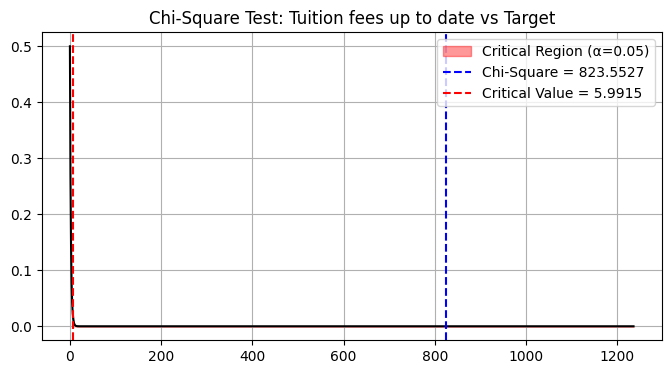

Bias-Corrected Cramér's V : 0.4310 → Very strong


In [ ]:
chi_square_test(df_eda, 'Tuition fees up to date', 'Target', alpha=0.05)

Uji Chi-Square
Chi-Square = 823.55 jauh melampaui nilai kritis 5.99 dengan p-value < 0.001, artinya hubungan antara status pembayaran uang kuliah dan dropout terbukti signifikan secara statistik. Cramér's V = 0.431 menunjukkan kekuatan hubungan yang very strong dan paling tinggi dibanding fitur kategorikal lainnya.

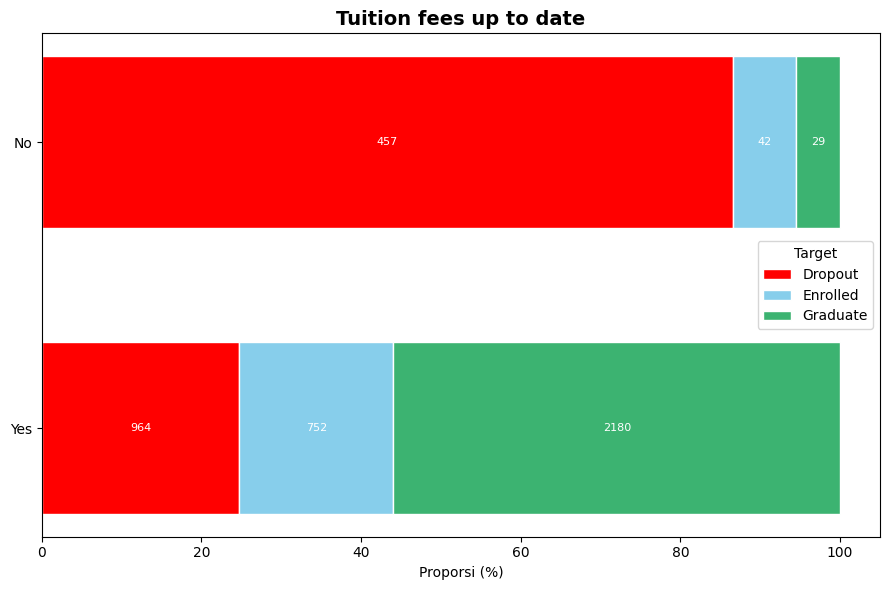

In [ ]:
interpretasi_kategorik(df_eda, 'Tuition fees up to date', 'Tuition fees up to date')

Perbedaan proporsi antara kedua kategori sangat ekstrem. Mahasiswa yang tidak membayar tepat waktu (No) didominasi Dropout 87% (457 mahasiswa), dengan hanya sedikit mahasiswa yang Enrolled (42) atau Graduate (29). Sementara mahasiswa yang membayar tepat waktu (Yes) justru sebaliknya, mayoritas Graduate 56% (2180 mahasiswa) dan Dropout hanya 25% (964 mahasiswa).


Ketidakmampuan membayar uang kuliah adalah indikator risiko dropout paling kuat dalam dataset ini. Mahasiswa yang menunggak kemungkinan besar sedang menghadapi tekanan finansial yang tidak hanya menghambat studi secara administratif, tetapi juga mempengaruhi konsentrasi dan motivasi belajar. Secara operasional, status pembayaran uang kuliah bisa dijadikan trigger utama untuk intervensi dini, begitu terdeteksi menunggak, institusi bisa langsung menghubungi mahasiswa untuk konseling finansial atau program beasiswa darurat sebelum kondisi memburuk.

**16. Gender**

Contingency Table:
Target  Dropout  Enrolled  Graduate
Gender                             
Female      720       487      1661
Male        701       307       548

Chi-Square : 233.2664
P-Value    : < 0.001
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Tolak H0 → Dependen


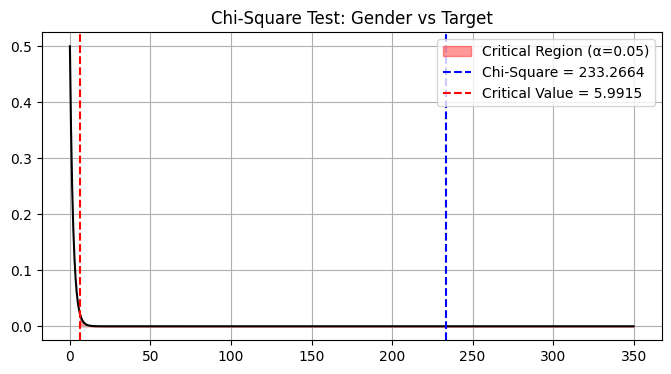

Bias-Corrected Cramér's V : 0.2287 → Strong


In [ ]:
chi_square_test(df_eda, 'Gender', 'Target', alpha=0.05)

Chi-Square = 233.27 jauh melampaui nilai kritis 5.99 dengan p-value < 0.001. Cramér's V = 0.2287 menunjukkan hubungan yang strong antara jenis kelamin dan dropout.

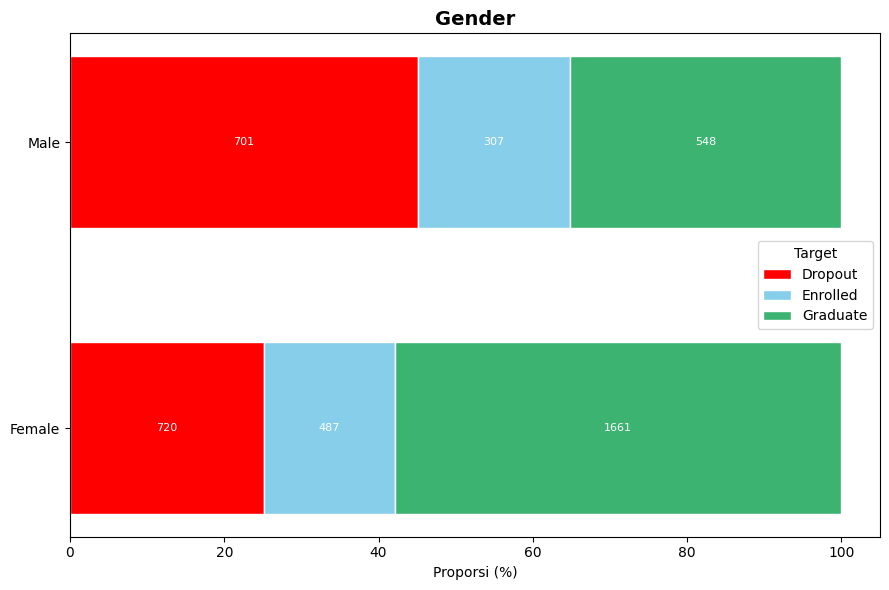

In [ ]:
interpretasi_kategorik(df_eda, 'Gender', 'Gender')

Mahasiswa perempuan (2.868 orang) memiliki proporsi Graduate jauh lebih tinggi (58%) dan Dropout lebih rendah (25%) dibanding laki-laki (1.556 orang) yang Dropout-nya mencapai 45% dengan Graduate hanya 35%.

Perbedaan yang sangat mencolok ini menunjukkan bahwa jenis kelamin adalah prediktor yang kuat. Mahasiswa laki-laki memiliki risiko dropout hampir dua kali lebih tinggi dibanding perempuan dalam dataset ini. Perbedaan ini bisa mencerminkan pola belajar, motivasi, pilihan jurusan, atau tekanan sosial-ekonomi yang berbeda antara kedua jenis kelamin. Fitur ini layak masuk sebagai salah satu prediktor penting dalam model.



---



**17. Scholarship holder**

Contingency Table:
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
No                     1287       664      1374
Yes                     134       130       835

Chi-Square : 409.9431
P-Value    : < 0.001
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Tolak H0 → Dependen


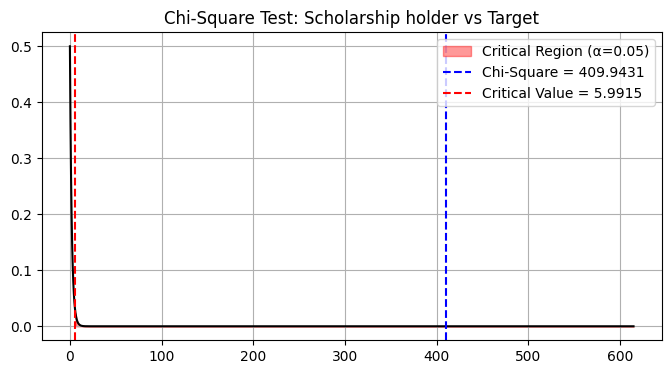

Bias-Corrected Cramér's V : 0.3037 → Very strong


In [ ]:
chi_square_test(df_eda, 'Scholarship holder', 'Target', alpha=0.05)

Chi-Square = 409.94 jauh melampaui nilai kritis 5.99 dengan p-value < 0.001. Cramér's V = 0.3037 menunjukkan hubungan yang very strong antara status beasiswa dan dropout — tertinggi di antara semua fitur kategorikal.

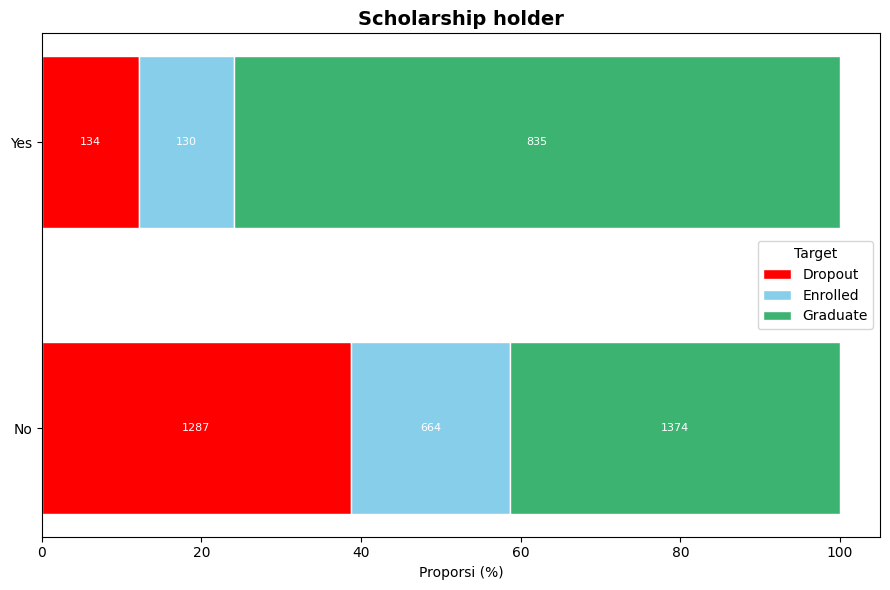

In [ ]:
interpretasi_kategorik(df_eda, 'Scholarship holder', 'Scholarship holder')

Mahasiswa penerima beasiswa (Yes) didominasi Graduate (76%, 835 mahasiswa) dengan Dropout hanya 12% (134 mahasiswa). Sebaliknya, mahasiswa tanpa beasiswa (No) proporsi Dropout-nya jauh lebih tinggi mencapai 39% (1287 mahasiswa).

Beasiswa terbukti menjadi faktor protektif yang signifikan terhadap dropout. Mahasiswa penerima beasiswa tidak hanya terbebas dari tekanan finansial, tetapi kemungkinan juga memiliki motivasi lebih tinggi untuk mempertahankan prestasinya agar beasiswa tidak dicabut. Secara operasional, program beasiswa bisa dijadikan salah satu bentuk intervensi preventif mahasiswa berisiko dropout.



---



**18. International**

Contingency Table:
Target         Dropout  Enrolled  Graduate
International                             
No                1389       770      2155
Yes                 32        24        54

Chi-Square : 1.2799
P-Value    : 0.5273
Df         : 2
Nilai Kritis (α=0.05): 5.9915
Keputusan  : Terima H0 → Independen


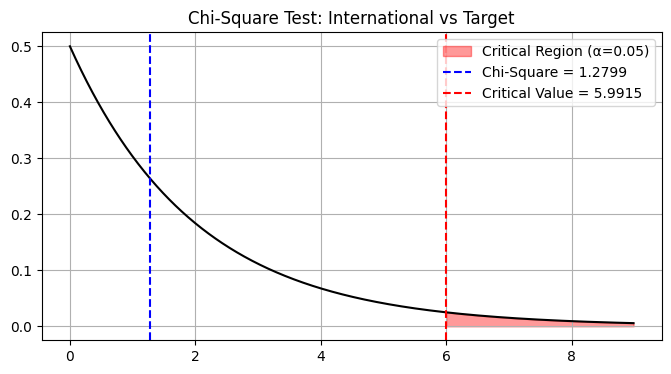

Bias-Corrected Cramér's V : 0.0000 → No or very weak


In [ ]:
chi_square_test(df_eda, 'International', 'Target', alpha=0.05)

Chi-Square = 1.28 berada jauh di bawah nilai kritis 5.99 dengan p-value = 0.527 (> 0.05). Terima H0 — tidak ada hubungan yang signifikan antara status mahasiswa internasional dan dropout. Cramér's V = 0.000 mengkonfirmasi tidak ada asosiasi sama sekali.

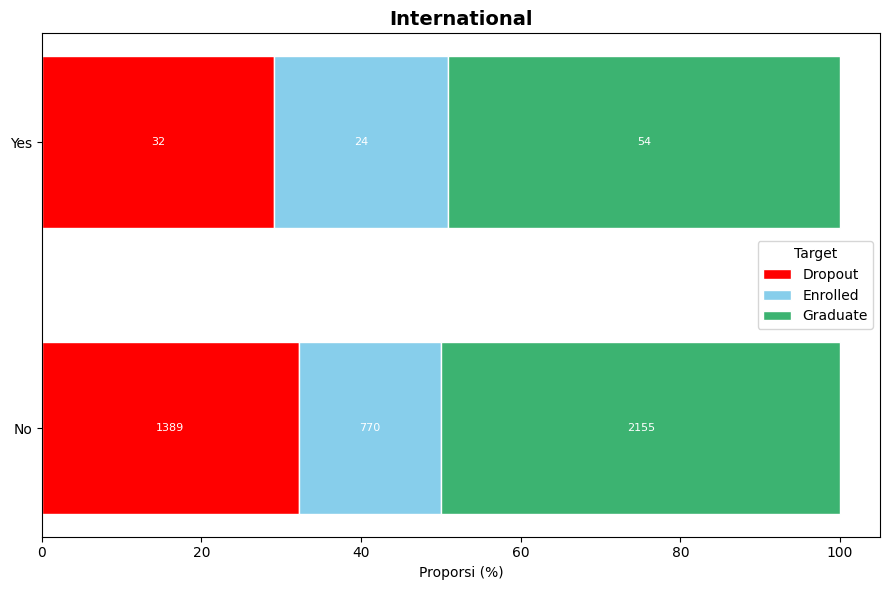

In [ ]:
interpretasi_kategorik(df_eda, 'International', 'International')

Proporsi Dropout antara mahasiswa internasional (Yes: 29%) dan lokal (No: 32%) hampir tidak berbeda. Mahasiswa internasional berjumlah sangat sedikit (110 orang atau ~2.5% dari total), sehingga tidak cukup representatif untuk menghasilkan sinyal statistik yang bermakna.

Karena tidak ada hubungan yang signifikan dan jumlah sampelnya sangat kecil, fitur International tidak perlu dimasukkan ke dalam model prediksi dropout. Ini juga konsisten dengan temuan pada Nationality yang menunjukkan dominasi mahasiswa Portugal dalam dataset.

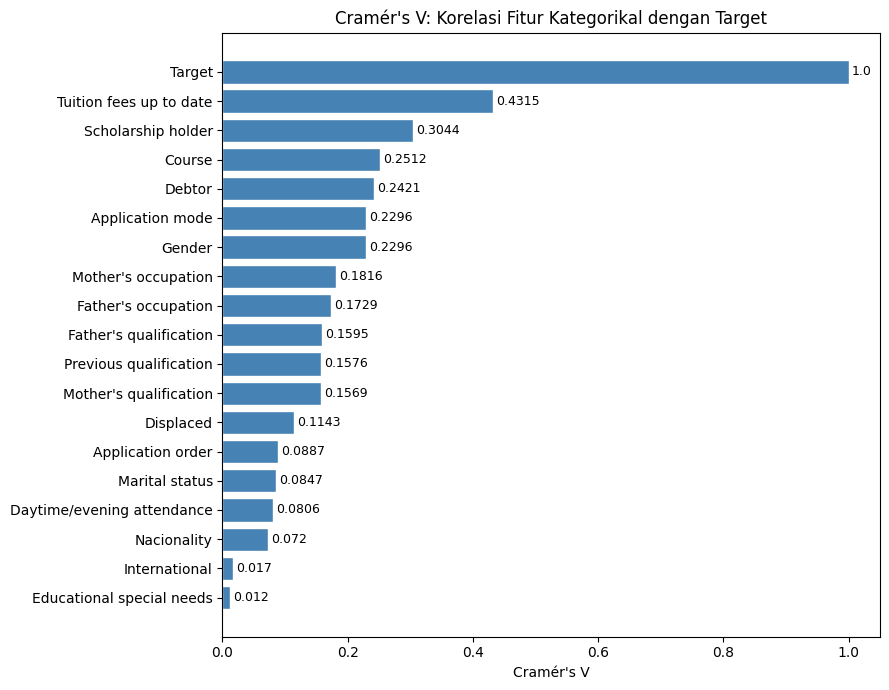

In [ ]:
cat_cols = df_eda.select_dtypes(include='category').columns.tolist()
cramers_v_target = {}
for col in cat_cols:
    ct = pd.crosstab(df_eda[col], df_eda['Target'])
    chi2 = stats.chi2_contingency(ct)[0]
    n = len(df_eda)
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    cramers_v_target[col] = round(v, 4)

ranking = pd.Series(cramers_v_target).sort_values()

plt.figure(figsize=(9, 7))
plt.barh(ranking.index, ranking.values, color='steelblue', edgecolor='white')

for i, (col, val) in enumerate(ranking.items()):
    plt.text(val + 0.005, i, str(val), va='center', fontsize=9)

plt.title("Cramér's V: Korelasi Fitur Kategorikal dengan Target")
plt.xlabel("Cramér's V")
plt.tight_layout()
plt.show()



---



**Heatmap Bias-Corrected Cramér's V untuk Fitur-Fitur Kategorikal**

In [ ]:
# Install dython library if not already installed
!pip install dython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 102.3 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas

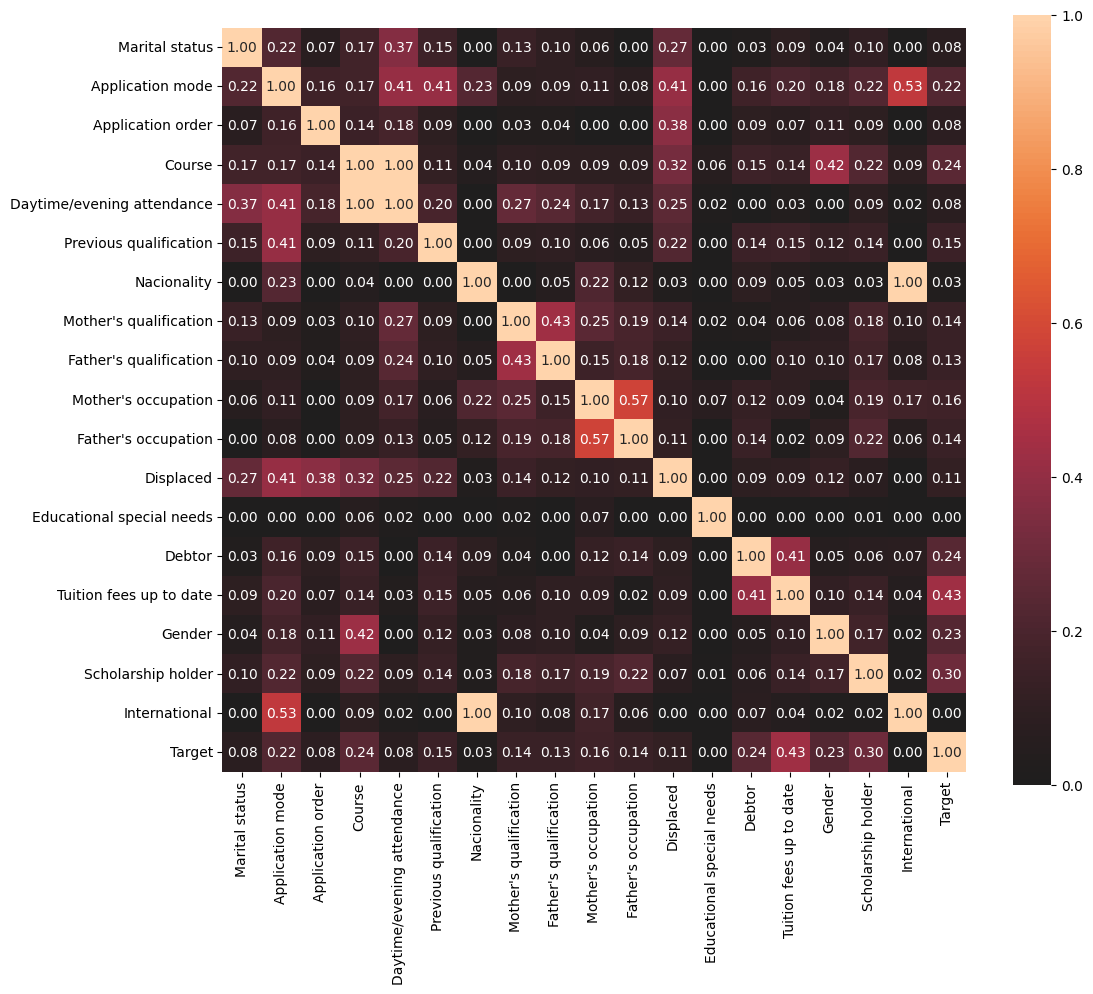

{'corr':                             Marital status  Application mode  \
 Marital status                    1.000000          0.223983   
 Application mode                  0.223983          1.000000   
 Application order                 0.069859          0.160752   
 Course                            0.167203          0.167711   
 Daytime/evening attendance        0.365826          0.410395   
 Previous qualification            0.154751          0.412110   
 Nacionality                       0.000000          0.233906   
 Mother's qualification            0.134379          0.087873   
 Father's qualification            0.098422          0.094428   
 Mother's occupation               0.056835          0.105881   
 Father's occupation               0.000000          0.077387   
 Displaced                         0.274844          0.411082   
 Educational special needs         0.000000          0.000000   
 Debtor                            0.030428          0.163959   
 Tuition fees up 

In [ ]:
from dython.nominal import associations

cat_cols = df_eda.select_dtypes(include='category').columns.tolist()

associations(df_eda[cat_cols], figsize=(12, 10))

Heatmap ini menggunakan Cramér's V sebagai ukuran kekuatan hubungan antar fitur kategorikal, termasuk dengan Target. Berbeda dengan korelasi Pearson yang hanya bisa digunakan untuk fitur numerik, Cramér's V dirancang khusus untuk mengukur seberapa kuat asosiasi antara dua variabel kategorikal, nilainya berkisar 0 (tidak ada hubungan) sampai 1 (hubungan sempurna).

##Kesimpulan

Tujuan bisnis utama proyek ini adalah menekan angka putus kuliah melalui deteksi dini, di mana penggunaan data akademik Semester 1 menjadi kunci karena sudah cukup representatif untuk memprediksi kegagalan tanpa harus menunggu hasil Semester 2 yang cenderung serupa. Analisis menunjukkan bahwa hambatan finansial seperti status pembayaran SPP (Tuition fees) dan kepemilikan beasiswa merupakan faktor penentu yang paling kuat dalam memicu keputusan mahasiswa untuk berhenti. Dengan fokus pada variabel-variabel krusial ini dan mengabaikan informasi yang berulang, pihak kampus dapat lebih cepat mengidentifikasi profil mahasiswa berisiko dan memberikan intervensi yang tepat sasaran demi menjaga tingkat kelulusan.

## References
1. Martins, M. V., Tolledo, D., Machado, J., Baptista, V., & Realinho, V. (2022).  
   **Early Prediction of Student Dropout in Higher Education Using Machine Learning.**  
   Data, 7(11), 146.  
   https://doi.org/10.3390/data7110146
2. Ardiansyah, et al. (2023).  
   **Predicting Students Academic Success and Dropout Using Supervised Machine Learning.**  
   Journal of Informatics.  
   https://doi.org/10.37859/jf.v15i3.10714
3. Kaur, P., et al. (2023).  
   **Machine Learning Approaches for Predicting Student Performance and Dropout Risk.**  
   Discover Artificial Intelligence.  
   https://link.springer.com/article/10.1007/s44163-023-00079-z
4. ResearchGate Study. (2024).  
   **Predicting Students Academic Success and Dropout Using Supervised Machine Learning.**  
   https://www.researchgate.net/publication/384055745_Predicting_Students_Academic_Success_and_Dropout_Using_Supervised_Machine_Learning